# PREDICT HOUSE PRICE AND AWS DEPLOYMENT

## **Danh sách sinh viên**

| **TÊN**                  | **MSSV**      |
|-------------------------|---------------|
| Đỗ Nhật Nam             | 22110122      |
| Trần Trí Tân            | 22110199      |
| Nguyễn Huỳnh Đức Tân    | 22110197      |
| Trần Phương Thảo        | 22110207      |
| Dương Thị Thắm          | 22110200      |

## Mô tả Project

Hiện nay, nhu cầu bất động sản ở Việt Nam đang tăng lên do nhiều nguyên nhân như nhu cầu về mua nhà để ở, đầu tư bất động sản hoặc nhu cầu thuê nhà. Trong cả nước, các dự án bất động sản được đầu tư liên tục, bao gồm các khu dân cư, chung cư, khu phức hợp thương mại và các khu công nghiệp. Ngoài ra, nhu cầu về các loại bất động sản cao cấp cũng đang tăng lên do nhu cầu của giới thượng lưu và người nước ngoài.

Hơn nữa nhận thấy rằng, nhu cầu cầu bất động sản về nhà ở luôn là một trong những nhu cầu thiết yếu của cuộc sống. Trong đó, giá nhà là một trong những yếu tố quan trọng nhất trong quyết định mua nhà hoặc đầu tư bất động sản và thường có những biến động phức tạp và khó đoán trước trên thị trường bất động sản. Việc dự đoán giá nhà sẽ giúp người mua nhà và nhà đầu tư đưa ra quyết định thông minh và được tối ưu hóa. Người dân thông thường cũng có nhu cầu dự đoán giá nhà để chuẩn bị cho việc mua nhà trong tương lai hoặc định giá cho nhà của mình. Đồng thời, việc dự đoán giá nhà sẽ giúp cho các chuyên gia có thể dự báo được xu thế giá và phân tích thị trường một cách chính xác hơn. Các nhà đầu tư bất động sản, các công ty tài chính và ngân hàng cần phải định giá bất động sản để đưa ra quyết định về vấn đề cho vay và đầu tư. Việc dự đoán giá nhà sẽ giúp họ đưa ra các quyết định này một cách chính xác và an toàn hơn. Chính vì thế, việc xây dựng một model đự đoán giá nhà là rất hữu ích và cần thiết. Lợi ích của model dự đoán giá nhà mang lại:
- Hỗ trợ người mua nhà và nhà đầu tư trong việc đưa ra quyết định thông minh và nắm bắt được xu thế giá nhà trên thị trường.

- Giúp các chuyên gia bất động sản và các chuyên gia đầu tư phân tích thị trường bất động sản một cách chính xác và hiệu quả hơn.

- Xác định giá trị cũng như tiềm năng phát triển của một căn nhà cụ thể hoặc của một khu vực bất động sản nào đó.

- Cung cấp thông tin hữu ích cho các công ty, ngân hàng và tổ chức tài chính trong việc đánh giá và định giá bất động sản.

- Hỗ trợ trong việc tạo ra các kế hoạch đầu tư và phát triển bất động sản.

- Cải thiện quá trình quản lý rủi ro và giảm rủi ro cho các nhà đầu tư bất động sản.

- Cung cấp dữ liệu và thông tin cho các lĩnh vực khác như bảo hiểm nhà, định giá tài sản và dịch vụ kế toán.

-> Tóm lại, mô hình dự đoán giá nhà là một công cụ hữu ích và cần thiết để giúp người mua,các chuyên gia bất động sản và các nhà đầu tư có thể hiểu rõ hơn về thị trường bất động sản và đưa ra quyết định đầu tư và kinh doanh thông minh hơn.


## Library

In [77]:
import pandas as pd
import numpy as np
from numpy import median
import re

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
import seaborn as sns

#Plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.figure_factory as ff
#Subplots
from plotly.subplots import make_subplots

from scipy.stats import f_oneway
from scipy import stats

#Mutual Information function
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import normalized_mutual_info_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

## Load data

In [78]:
data = pd.read_csv('original_data.csv')

## Overview

In [79]:
import geopandas as gpd
geojson = 'diaphanhuyen.geojson'
geojson_data = gpd.read_file(geojson)

In [80]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geopandas import GeoDataFrame


import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_vietnam_house_price_map(geojson_data: GeoDataFrame, house_price_data: pd.DataFrame, output_path: str):

    # Standardize and clean province names in geojson_data
    geojson_data["Ten_Tinh"] = (
        geojson_data["Ten_Tinh"]
        .str.replace("- ", "", regex=False)
        .str.replace("Tỉnh ", "", regex=False)
        .str.replace("TP. ", "", regex=False)
        .str.strip()
    )

    # Standardize province names in house_price_data
    house_price_data["province"] = house_price_data["province"].str.strip()

    # Calculate average house price by province
    avg_price_by_province = house_price_data.groupby("province")["price"].mean().reset_index()
    avg_price_by_province = avg_price_by_province.rename(columns={"price": "avg_price"})

    # Merge GeoDataFrame with average house price data
    vietnam_house_price = geojson_data.merge(
        avg_price_by_province, left_on="Ten_Tinh", right_on="province", how="left"
    )

    # Handle missing data (fill NaN values with 0 for visualization)
    vietnam_house_price["avg_price"] = vietnam_house_price["avg_price"].fillna(0)

    # Plot the choropleth map
    fig, ax = plt.subplots(figsize=(15, 15))
    vietnam_house_price.plot(
        column="avg_price",
        cmap="YlOrRd",
        legend=True,
        legend_kwds={
            "label": "Giá nhà trung bình (VND)",  # Label for the legend
            "shrink": 0.8,                       # Shrink the size of the legend
        },
        ax=ax,
        edgecolor="black",
        missing_kwds={
            "color": "lightgrey",  # Color for missing data
            "label": "Không có dữ liệu"  # Label for missing data
        },
    )
    ax.set_axis_off()  # Turn off axis
    ax.set_title("Bản đồ giá nhà trung bình tại Việt Nam", fontsize=16)

    # Save the output map
    plt.savefig(output_path, bbox_inches="tight", dpi=300)
    print(f"Bản đồ đã được lưu vào {output_path}")


### Original data

In [81]:
# Đổi tên cột của DataFrame cho thuận tiện sử dụng
data.columns = data.columns.str.lower().str.replace(' ', '_')
data.columns

Index(['address', 'area', 'frontage', 'access_road', 'house_direction',
       'balcony_direction', 'floors', 'bedrooms', 'bathrooms', 'legal_status',
       'furniture_state', 'price'],
      dtype='object')

In [82]:
data.head()

,address,area,frontage,access_road,house_direction,balcony_direction,floors,bedrooms,bathrooms,legal_status,furniture_state,price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [83]:
data.shape

(30229, 12)

- Dữ liệu có 30229 dòng và 12 cột

In [84]:
data.columns

Index(['address', 'area', 'frontage', 'access_road', 'house_direction',
       'balcony_direction', 'floors', 'bedrooms', 'bathrooms', 'legal_status',
       'furniture_state', 'price'],
      dtype='object')

| **Thuộc tính**           | **Mô tả chi tiết**                                                                                      |
|---------------------------|--------------------------------------------------------------------------------------------------------|
| **address**               | Địa chỉ đầy đủ của bất động sản, bao gồm thông tin như tên dự án, đường, phường, quận, và thành phố.   |
| **area**             | Tổng diện tích của bất động sản, được đo bằng mét vuông.                                              |
| **frontage**              | Chiều rộng của mặt trước bất động sản, được đo bằng mét.                                              |
| **access_road**             | Chiều rộng của đường dẫn vào bất động sản, được đo bằng mét.                                          |
| **house_direction**             | Hướng của mặt trước ngôi nhà (ví dụ: Đông, Tây, Nam, Bắc).                                            |
| **balcony_direction**        | Hướng của ban công ngôi nhà.                                                                          |
| **floors**               | Tổng số tầng của bất động sản.                                                                        |
| **bedrooms**          | Số lượng phòng ngủ trong bất động sản.                                                                |
| **bathrooms**          | Số lượng phòng tắm trong bất động sản.                                                                |
| **legal_status**    | Tình trạng pháp lý của bất động sản, như đã có giấy chứng nhận quyền sở hữu hoặc đang trong hợp đồng mua bán. |
| **furniture_state**   | Tình trạng nội thất trong bất động sản, như đầy đủ nội thất, nội thất một phần, hoặc không có nội thất. |
| **price**                   | Giá của bất động sản, được biểu thị bằng đơn vị tỷ đồng Việt Nam (VND).                               |


In [85]:
# Tạo cột project (dự án)
data['project'] = data['address'].str.lower().str.contains('dự án').map({True: 1, False: 0})

data['address'] = data['address'].str.replace('dự án', '', case=False, regex=False)

In [86]:
# Tạo 1 cột mới chứa thông tin tỉnh của địa chỉ
data['province'] = data["address"].apply(lambda x: x.split(',')[-1].strip())

# Xóa dấu chấm ở cuối
data["address"] = data["address"].apply(lambda x: re.sub(r"\.+$", "", x))
data['province'] = data['province'].apply(lambda x: re.sub(r"\.+$", "", x))
data.drop(columns=['address'], inplace=True)

# Bỏ đi các tỉnh có ít hơn 5 mẫu
data = data.groupby('province').filter(lambda x: len(x) >= 10)
data["province"].unique()

print(f"Tỉnh/Thành phố: {pd.unique(data['province'])}")
print("Số tỉnh thành: ", len(pd.unique(data['province'])))

Tỉnh/Thành phố: ['Hưng Yên' 'Hồ Chí Minh' 'Hà Nội' 'Quảng Ninh' 'Bình Dương' 'Phú Thọ'
 'Hải Dương' 'Long An' 'Kiên Giang' 'Bình Thuận' 'Hải Phòng' 'Hà Nam'
 'Bà Rịa Vũng Tàu' 'Đắk Lắk' 'Bắc Ninh' 'Thanh Hóa' 'Khánh Hòa' 'Đà Nẵng'
 'Thái Nguyên' 'Quảng Trị' 'Đồng Nai' 'Ninh Thuận' 'Nghệ An' 'Cần Thơ'
 'Thái Bình' 'Bắc Giang' 'Lâm Đồng' 'Quảng Nam' 'Hòa Bình'
 'Thừa Thiên Huế' 'Bình Định' 'Vĩnh Phúc' 'Tây Ninh' 'Tiền Giang'
 'Hà Tĩnh' 'Lào Cai' 'Phú Yên']
Số tỉnh thành:  37


- Chuyển cột address thành cột province để thực hiện so sánh giá nhà giữa các tỉnh
- Bỏ đi những tỉnh có ít hơn 10 nhà bán vì không mang nhiều thông tin tổng thể
- **Sau khi chuyển thành province thì ta có 37 tỉnh thành**

### New data

#### Thêm biến dân số

In [87]:
population_data = pd.read_csv('population.csv')

In [88]:
# Kết hợp dữ liệu với dữ liệu dân số
data = data.merge(population_data, on='province', how='left')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30113 entries, 0 to 30112
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                30113 non-null  float64
 1   frontage            18584 non-null  float64
 2   access_road         16863 non-null  float64
 3   house_direction     8915 non-null   object 
 4   balcony_direction   5200 non-null   object 
 5   floors              26535 non-null  float64
 6   bedrooms            24977 non-null  float64
 7   bathrooms           23068 non-null  float64
 8   legal_status        25626 non-null  object 
 9   furniture_state     16061 non-null  object 
 10  price               30113 non-null  float64
 11  project             30113 non-null  int64  
 12  province            30113 non-null  object 
 13  population          30113 non-null  int64  
 14  population_density  30113 non-null  int64  
dtypes: float64(7), int64(3), object(5)
memory usage: 3.4+

In [89]:
print(data['population_density'].nunique())

37


In [90]:
data.head(5)

,area,frontage,access_road,house_direction,balcony_direction,floors,bedrooms,bathrooms,legal_status,furniture_state,price,project,province,population,population_density
0,84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60,1,Hưng Yên,1290850,1388
1,60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50,1,Hưng Yên,1290850,1388
2,90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90,1,Hưng Yên,1290850,1388
3,54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35,0,Hồ Chí Minh,9389720,4481
4,92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90,0,Hồ Chí Minh,9389720,4481


Kiểm tra các cột mới

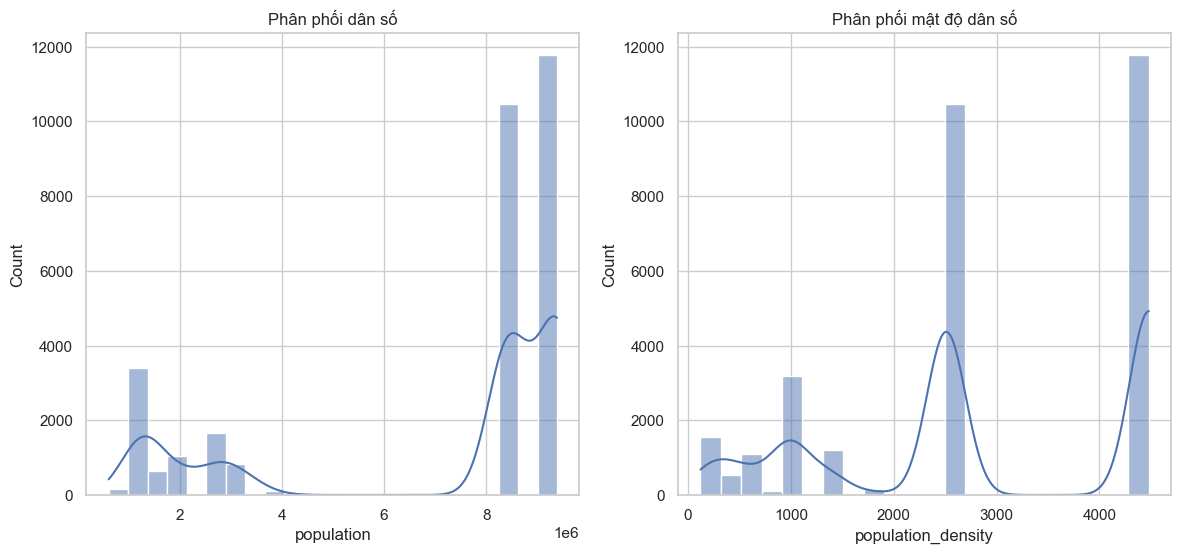

In [91]:
# Phân phối của dân số và mật độ dân số
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(data['population'], kde=True, ax=ax[0])
ax[0].set_title('Phân phối dân số')
sns.histplot(data['population_density'], kde=True, ax=ax[1])
ax[1].set_title('Phân phối mật độ dân số')
plt.show()

- Ta có thể thấy 2 giá trị cao bất thường dẫn đến dữ liệu có xu hướng lệch trái.

- 2 giá trị này là 2 thành phố lớn Hà Nội và Hồ Chí Minh

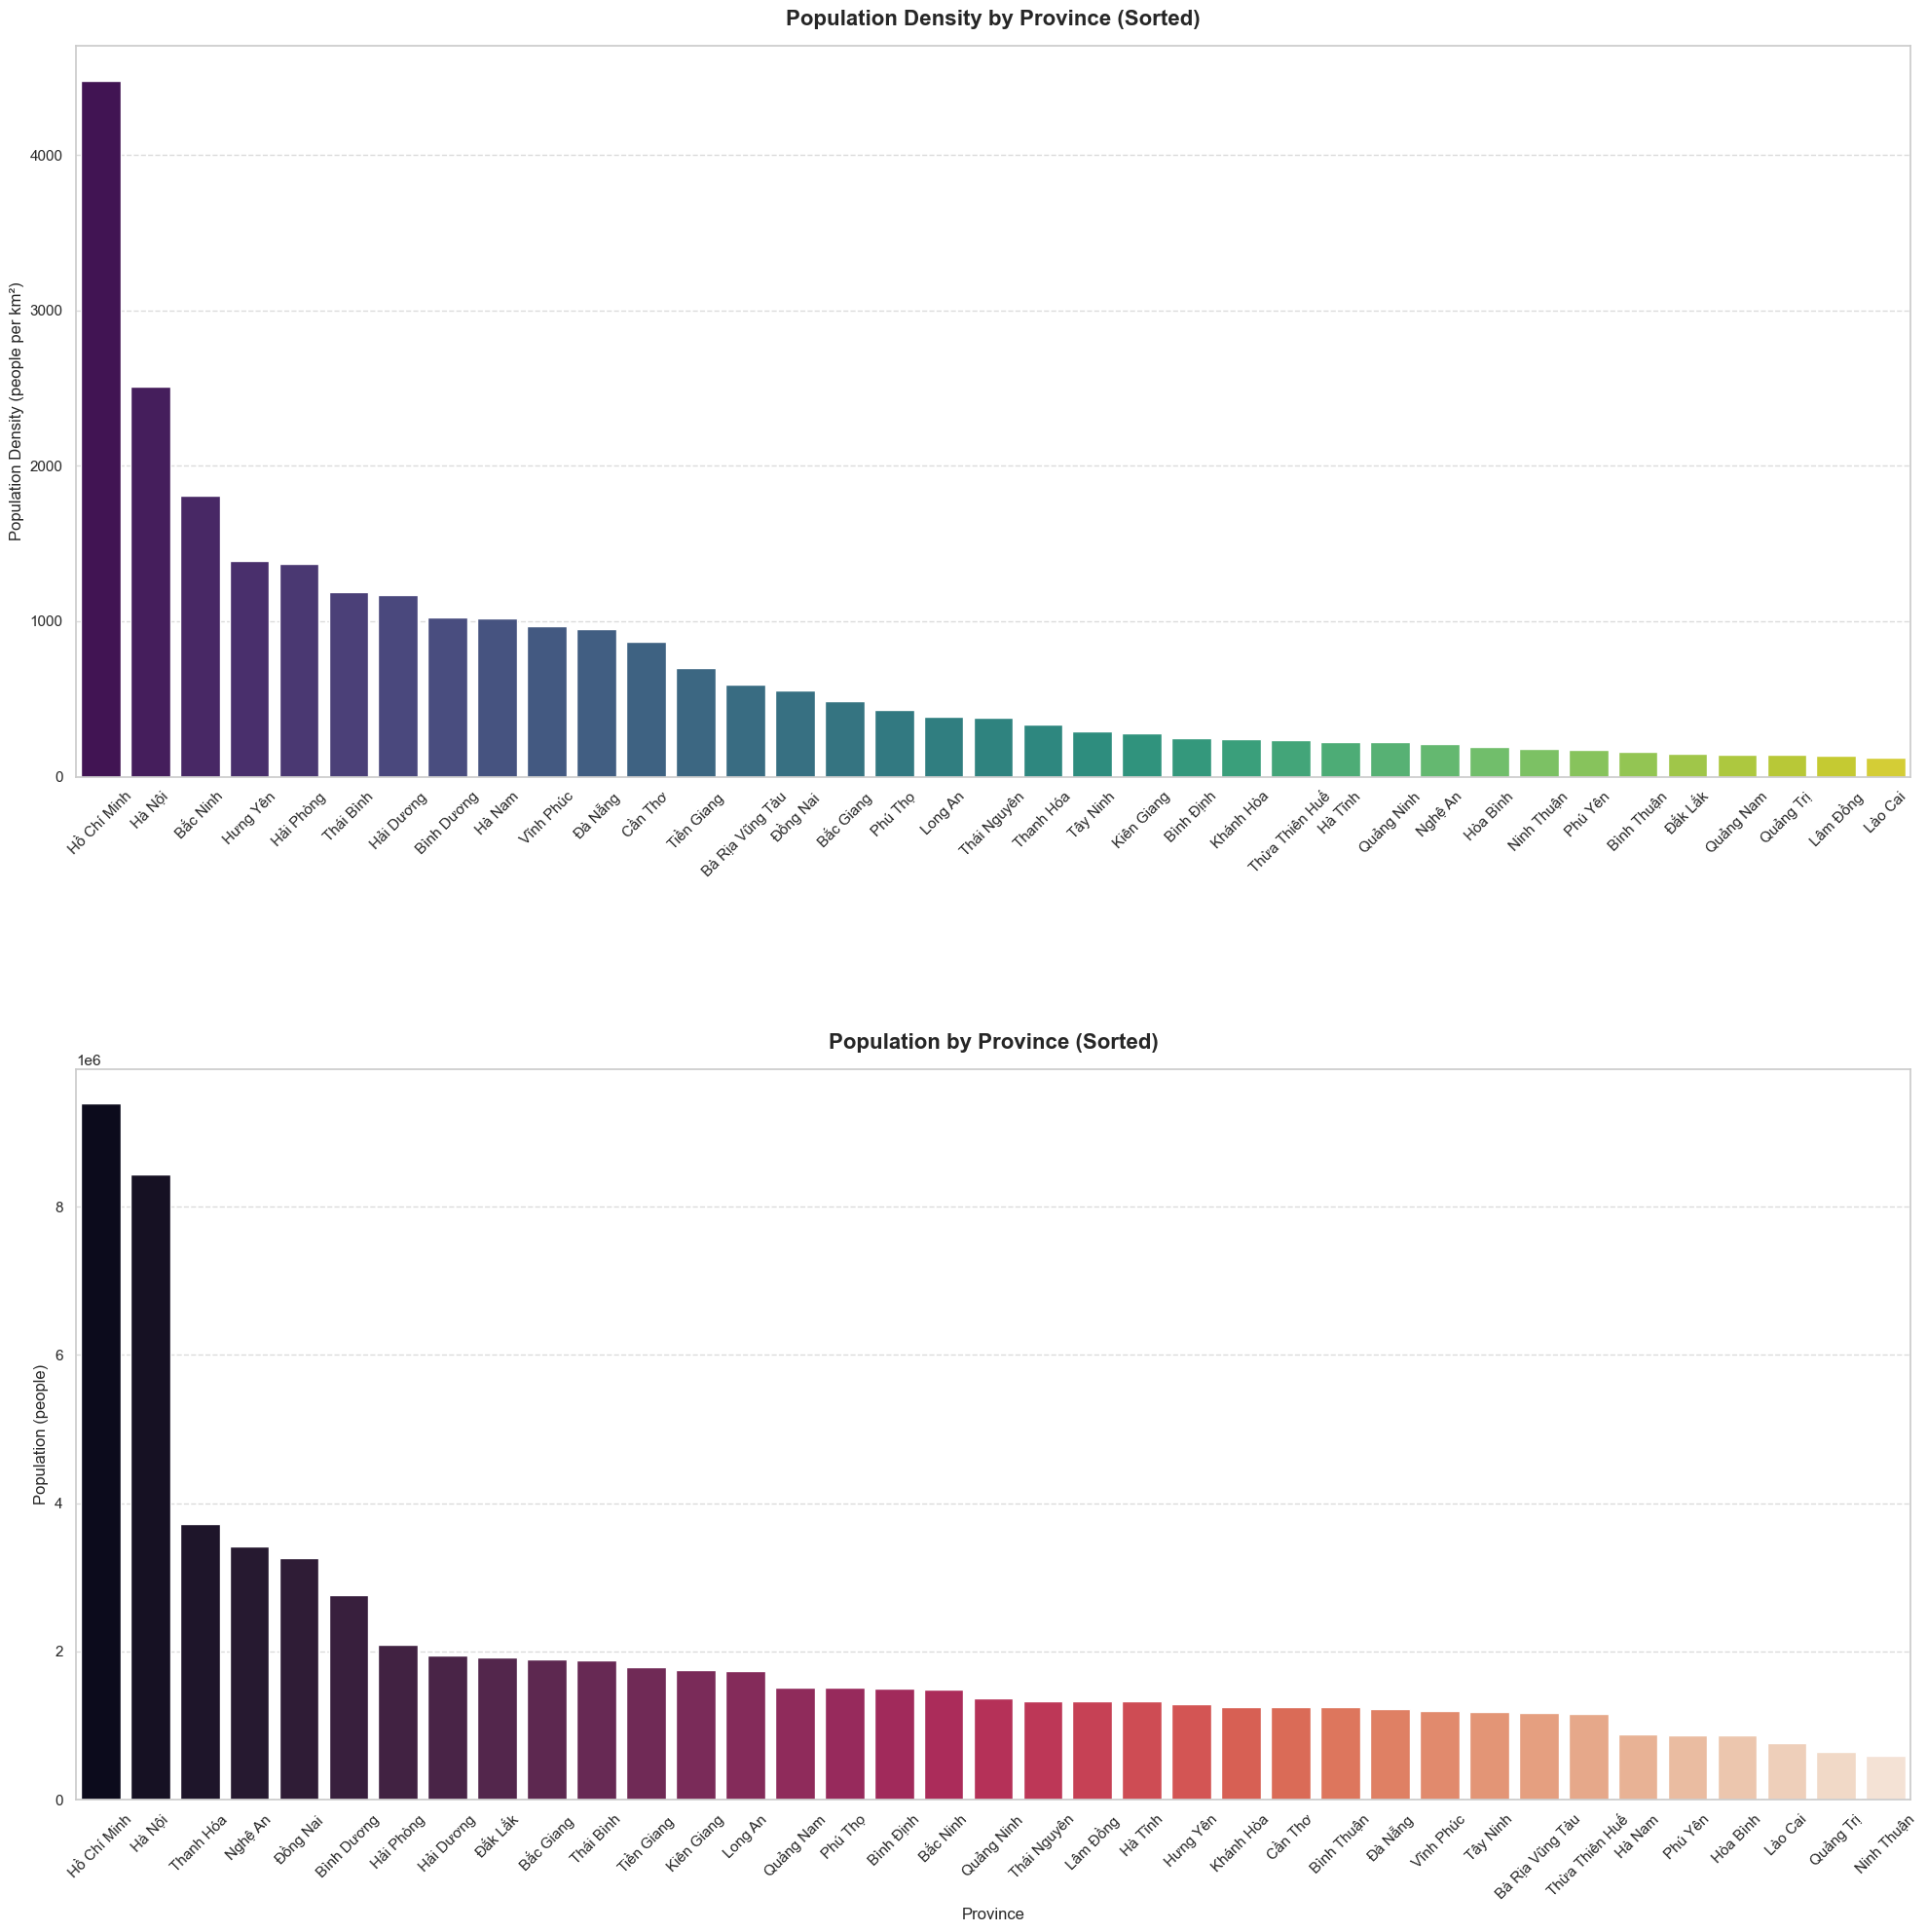

In [92]:
# Sắp xếp dữ liệu theo mật độ dân số và dân số
data_density_sorted = data.sort_values(by='population_density', ascending=False)
data_population_sorted = data.sort_values(by='population', ascending=False)

# Thiết lập phong cách chung
sns.set_theme(style="whitegrid")

# Tạo figure và các axes
fig, ax = plt.subplots(2, 1, figsize=(20, 20))

# Biểu đồ 1: Population Density by Province
sns.barplot(
    x='province',
    y='population_density',
    data=data_density_sorted,  # Sử dụng dữ liệu đã được sắp xếp
    ax=ax[0],
    palette="viridis"
)

# Tùy chỉnh trục và tiêu đề
ax[0].set_title('Population Density by Province (Sorted)', fontsize=16, fontweight='bold', pad=15)
ax[0].set_ylabel('Population Density (people per km²)', fontsize=12)
ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Biểu đồ 2: Population by Province
sns.barplot(
    x='province',
    y='population',
    data=data_population_sorted,  # Sử dụng dữ liệu đã được sắp xếp
    ax=ax[1],
    palette="rocket"
)


# Tùy chỉnh trục và tiêu đề
ax[1].set_title('Population by Province (Sorted)', fontsize=16, fontweight='bold', pad=15)
ax[1].set_ylabel('Population (people)', fontsize=12)
ax[1].set_xlabel('Province', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

# Tùy chỉnh chung cho layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # Điều chỉnh khoảng cách giữa các biểu đồ
plt.show()

- Các thành phố lớn như Hồ Chí Minh hay Hà Nội có dân cư đông đúc nhất


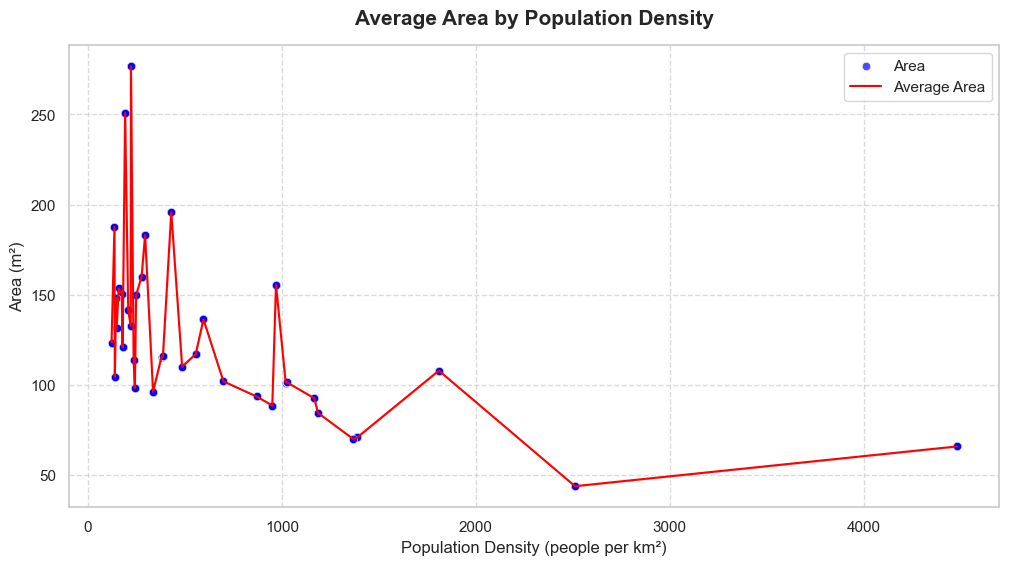

In [93]:
# Diện tích nhà trung bình nhà theo mật độ dân số
data['average_area_by_density'] = data.groupby('population_density')['area'].transform('mean')

# Vẽ biểu đồ scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='population_density', y='average_area_by_density', data=data, alpha=0.7, color='blue', label='Area')
sns.lineplot(x='population_density', y='average_area_by_density', data=data, color='red', label='Average Area')
plt.title('Average Area by Population Density', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Population Density (people per km²)', fontsize=12)
plt.ylabel('Area (m²)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

-  Ta có thể thấy các tỉnh càng có mật độ dân số dày đặc càng có diện tích nhà nhỏ

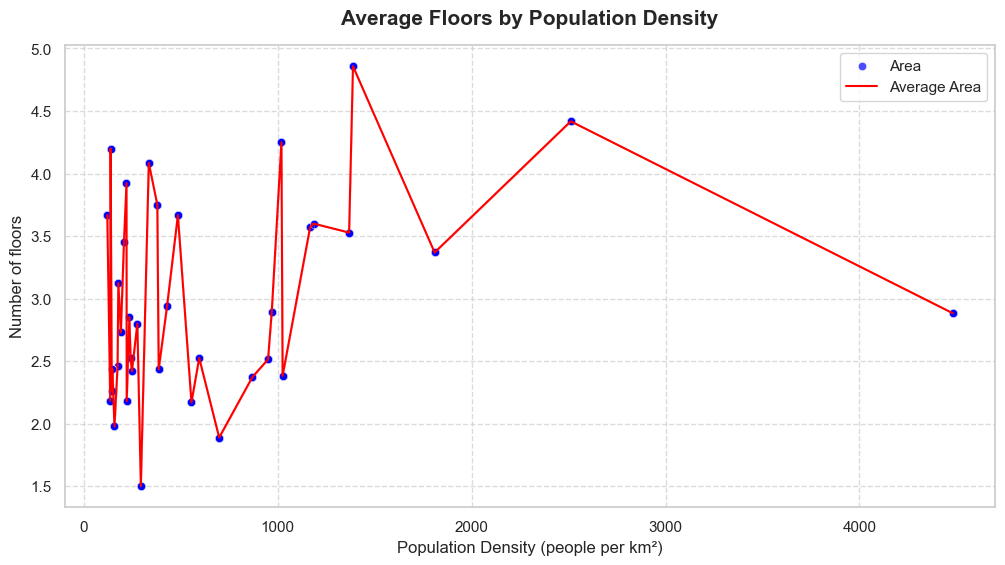

In [94]:
# Số lầu trung bình theo mật độ dân số
data['average_floors_by_density'] = data.groupby('population_density')['floors'].transform('mean')
# Vẽ biểu đồ scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='population_density', y='average_floors_by_density', data=data, alpha=0.7, color='blue', label='Area')
sns.lineplot(x='population_density', y='average_floors_by_density', data=data, color='red', label='Average Area')
plt.title('Average Floors by Population Density', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Population Density (people per km²)', fontsize=12)
plt.ylabel('Number of floors', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()


- Ta có thể thấy, khi ở những nơi mật độ dân số dày đặc thì việc xây nhà cao tầng sẽ giải quyết vấn đề về không gian sống.

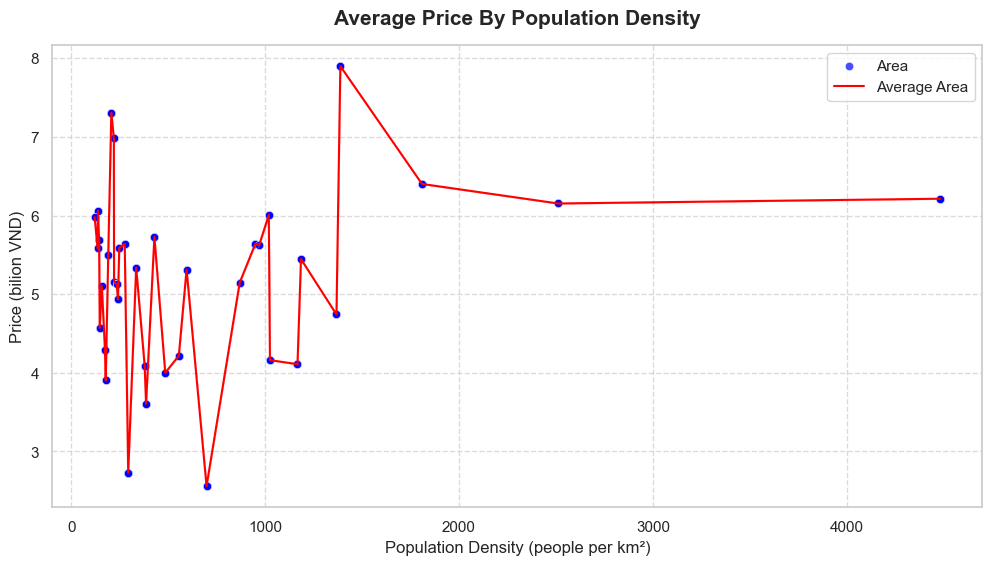

In [95]:
# Giá nhà trung bình theo mật độ dân số của các tỉnh

# Vẽ biểu đồ scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='population_density', y= data.groupby('population_density')['price'].transform('mean'), data=data, alpha=0.7, color='blue', label='Area')
sns.lineplot(x='population_density', y= data.groupby('population_density')['price'].transform('mean'), data=data, color='red', label='Average Area')
plt.title('Average Price By Population Density', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Population Density (people per km²)', fontsize=12)
plt.ylabel('Price (bilion VND)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

- Ở các thành phố càng đông dân cư canh tranh càng cao nên giá nhà càng cao

#### Thêm các khu vực

In [96]:
province_region_data = pd.read_csv('province_region.csv')

In [97]:
data = data.merge(province_region_data, on='province', how='left')

In [98]:
# Tần suất xuất hiện theo các khu vực
data['region'].value_counts().sort_values(ascending=False)

region
Đông Nam Bộ                             14538
Đồng bằng sông Hồng                     12044
Bắc Trung Bộ và Duyên hải miền Trung     2625
Đồng bằng sông Cửu Long                   557
Tây Nguyên                                195
Trung du và miền núi phía Bắc             154
Name: count, dtype: int64

- Các bật động sản tập trung chủ yếu ở 2 khu vực Đông Nam Bộ và Đồng bằng sông Hồng

- Điều này là hợp lý vì đây là khu vực tập trung của các thành phố lớn

In [99]:
# Giá nhà trung bình theo khu vực
data['average_price_by_region'] = data.groupby('region')['price'].transform('mean')

# Vẽ biểu đồ

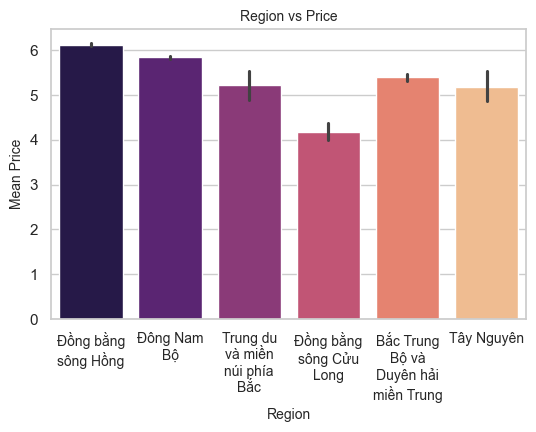

In [100]:
from statistics import mean
from textwrap import wrap  # Để tự động xuống dòng cho nhãn

fig = plt.figure(constrained_layout=True, figsize=(10, 10))
gs = GridSpec(3, 2, figure=fig)  # Lưới 3 hàng x 2 cột

# Biểu đồ 1: region vs price
ax = plt.subplot(gs[0, 0])
sns.barplot(data=data, x="region", y="price", estimator=mean, palette='magma', ax=ax)

# Gói (wrap) nhãn trục X thành nhiều dòng nếu tên quá dài
regions = data['region'].unique()  # Lấy danh sách các khu vực (region)
wrapped_labels = ['\n'.join(wrap(label, 10)) for label in regions]  # Xuống dòng sau mỗi 10 ký tự
ax.set_xticklabels(wrapped_labels, fontsize=10)

# Các tùy chỉnh khác
plt.xlabel("Region", fontsize=10)
plt.ylabel("Mean Price", fontsize=10)
plt.xticks(rotation=0)  # Không cần xoay nếu đã xuống dòng
plt.title("Region vs Price", fontsize=10)

plt.show()


In [101]:
# Kiểm tra khoảng tin cậy cho giá nhà trung bình theo khu vực
# Sử dụng bootstrap để ước lượng khoảng tin cậy 95%
def bootstrap_confidence_interval(data, estimator=np.mean, n_bootstraps=10000, ci=95):
    bootstraps = [estimator(data.sample(n=len(data), replace=True)) for _ in range(n_bootstraps)]
    alpha = 100 - ci
    lower = np.percentile(bootstraps, alpha / 2)
    upper = np.percentile(bootstraps, 100 - alpha / 2)
    return lower, upper

# Tính khoảng tin cậy 95% cho giá nhà trung bình theo khu vực
confidence_intervals = data.groupby('region')['price'].apply(bootstrap_confidence_interval)

# Hiển thị khoảng tin cậy
confidence_intervals.sort_values(ascending=False)

region
Đồng bằng sông Hồng                     (6.087781198106941, 6.1637552308203265)
Đông Nam Bộ                              (5.808426829687715, 5.881724153941395)
Bắc Trung Bộ và Duyên hải miền Trung     (5.309602380952381, 5.477642761904763)
Trung du và miền núi phía Bắc             (4.877332792207792, 5.54389935064935)
Tây Nguyên                               (4.830564102564103, 5.535501282051282)
Đồng bằng sông Cửu Long                 (3.9842540394973063, 4.360017953321364)
Name: price, dtype: object

- Ta có thể các khu vực như Bắc Trung Bộ và Duyên hải miền Trung, Trung du và miền núi phía Bắc, Tây Nguyên có trung bình giá nhà rất khó phân biệt. Do đó, ta sẽ gộp 3 nhóm này thành 1.


In [102]:
# Gộp  các khu vực có giá nhà trung bình không khác biệt nhau
data['region_grouped'] = data['region'].replace({
    "Đồng bằng sông Hồng": "A",
    "Đông Nam Bộ": "B",
    "Bắc Trung Bộ và Duyên hải miền Trung": "C",
    "Trung du và miền núi phía Bắc": "C",
    "Tây Nguyên": "C",
    "Đồng bằng sông Cửu Long": "D"
})

# Tính giá nhà trung bình theo khu vực gộp
data['average_price_by_region_grouped'] = data.groupby('region_grouped')['price'].transform('mean')

In [103]:
data['average_price_by_region_grouped'].unique()

array([6.12568831, 5.84504471, 5.37171486, 4.17095153])

In [104]:
data.drop(columns=['average_price_by_region'], inplace=True)

In [105]:
data['average_price_by_region_grouped'].value_counts()

average_price_by_region_grouped
5.845045    14538
6.125688    12044
5.371715     2974
4.170952      557
Name: count, dtype: int64

Ở đây ta có 2 loại dữ liệu
- float64
- object

Số cột có kiểu numerical là 10

Số cột có kiểu object là 5

Tuy nhiên, các cột như floors, bedrooms, bathrooms có giá trị rời rạc. Do đó nên được xử lý như các biến dạng phân loại sẽ tốt hơn

In [106]:
# Bỏ đi cột project khi tính skew
data.select_dtypes(include=['number']).drop(columns=['project']).skew()

area                               3.865311
frontage                           8.131389
access_road                        3.743166
floors                             0.007498
bedrooms                           1.054756
bathrooms                          0.751080
price                             -0.029828
population                        -1.081270
population_density                -0.220387
average_area_by_density            1.910759
average_floors_by_density          0.311648
average_price_by_region_grouped   -2.948027
dtype: float64

- Độ lệch cho chúng ta biết dữ liệu có hình dạng lệch trái, lệch phải hay có phân phối gần giống phân phối chuẩn
- Nếu skewness nhỏ hơn 0 thì dữ liệu lệch trái, lớn hơn 0 thì dữ liệu lệch phải. Bằng 0 thì dữ liệu gần phân phối chuẩn
- Trong dữ liệu trên, cột target (price) có độ lệch gần 0. Đây là điều kiện lý tưởng cho bài toán regression
- Cột frontage là có dữ liệu lệch phải đáng kể nhất

In [107]:
# Xử lý skewness cho các cột có skewness > 1
skewed_cols = data.select_dtypes(include=['number']).drop(columns=['project']).skew().sort_values(ascending=False)
skewed_cols = skewed_cols[skewed_cols > 1].index
data[skewed_cols] = np.log1p(data[skewed_cols])

data.select_dtypes(include=['number']).drop(columns=['project']).skew()

area                               0.637102
frontage                           3.158280
access_road                        0.888719
floors                             0.007498
bedrooms                          -0.104289
bathrooms                          0.751080
price                             -0.029828
population                        -1.081270
population_density                -0.220387
average_area_by_density            0.696759
average_floors_by_density          0.311648
average_price_by_region_grouped   -2.948027
dtype: float64

In [108]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geopandas import GeoDataFrame


import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_vietnam_house_price_map(geojson_data: GeoDataFrame, house_price_data: pd.DataFrame, output_path: str):

    # Standardize and clean province names in geojson_data
    geojson_data["Ten_Tinh"] = (
        geojson_data["Ten_Tinh"]
        .str.replace("- ", "", regex=False)
        .str.replace("Tỉnh ", "", regex=False)
        .str.replace("TP. ", "", regex=False)
        .str.strip()
    )

    # Standardize province names in house_price_data
    house_price_data["province"] = house_price_data["province"].str.strip()

    # Calculate average house price by province
    avg_price_by_province = house_price_data.groupby("province")["price"].mean().reset_index()
    avg_price_by_province = avg_price_by_province.rename(columns={"price": "avg_price"})

    # Merge GeoDataFrame with average house price data
    vietnam_house_price = geojson_data.merge(
        avg_price_by_province, left_on="Ten_Tinh", right_on="province", how="left"
    )

    # Handle missing data (fill NaN values with 0 for visualization)
    vietnam_house_price["avg_price"] = vietnam_house_price["avg_price"].fillna(0)

    # Plot the choropleth map
    fig, ax = plt.subplots(figsize=(15, 15))
    vietnam_house_price.plot(
        column="avg_price",
        cmap="YlOrRd",
        legend=True,
        legend_kwds={
            "label": "Giá nhà trung bình (VND)",  # Label for the legend
            "shrink": 0.8,                       # Shrink the size of the legend
        },
        ax=ax,
        edgecolor="black",
        missing_kwds={
            "color": "lightgrey",  # Color for missing data
            "label": "Không có dữ liệu"  # Label for missing data
        },
    )
    ax.set_axis_off()  # Turn off axis
    ax.set_title("Bản đồ giá nhà trung bình tại Việt Nam", fontsize=16)

    # Save the output map
    plt.savefig(output_path, bbox_inches="tight", dpi=300)
    print(f"Bản đồ đã được lưu vào {output_path}")


In [109]:
geojson = 'diaphanhuyen.geojson'
geojson_data = gpd.read_file(geojson)

Bản đồ đã được lưu vào vietnammap


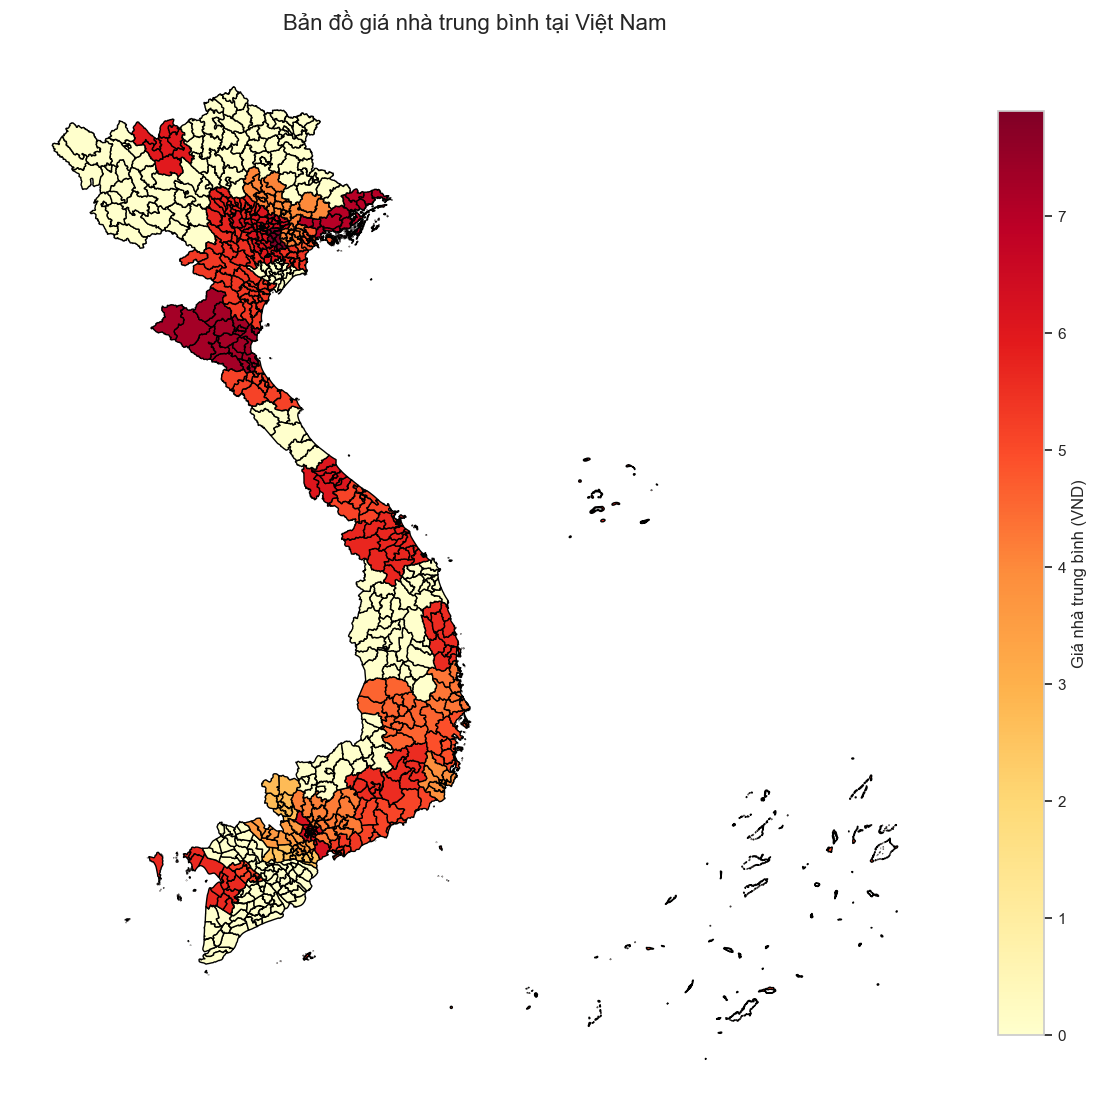

In [110]:
plot_vietnam_house_price_map(geojson_data,data,'vietnammap')

### Null value

In [111]:
data.isnull().sum().sum()

105188

- Dữ liệu ta có 105414 ô chứa giá trị Null. Đây là con số lớn nên ta cần phải xử lý cẩn thận

In [112]:
# Tạo 1 list chứa giá trị null của các cột
temp = list(data.isna().sum())

# Tạo 1 list chưa phần trăm null của các cột
temp_percent = [round((i/data.shape[0])*100,2) for i in temp]

# Tạo danh sách các cột và các giá trị còn thiếu của chúng dưới dạng danh sách bên trong thành một danh sách riêng
lst= []
i=0
for col in data.columns:
    insert_lst = [col,temp[i],temp_percent[i]]
    lst.append(insert_lst)
    i+=1

#Tạo dataframe
temp_data = pd.DataFrame(data=lst,columns=['Column_Name','Missing_Values', 'Missing_Values_Percent'])


In [113]:
# Các cột có giá trị null

temp_data[temp_data['Missing_Values']>0].sort_values(by='Missing_Values',ascending=False)\
                                        .reset_index(drop=True)\
                                        .style.background_gradient(cmap='Blues')\
                                        .format({'Missing_Values_Percent': '{:.2f}%'})

,Column_Name,Missing_Values,Missing_Values_Percent
0,balcony_direction,24913,82.73%
1,house_direction,21198,70.39%
2,furniture_state,14052,46.66%
3,access_road,13250,44.00%
4,frontage,11529,38.29%
5,bathrooms,7045,23.40%
6,bedrooms,5136,17.06%
7,legal_status,4487,14.90%
8,floors,3578,11.88%


- Có 9 cột chứa các giá trị Null
- Trong đó, các cột balcony_direction và house_direction có số số lượng ô null chiếm hơn 70%. Do đó ta có thể bỏ đi thay vì cố gắng điền khuyết. Vì kết quả dự đoán sẽ chỉ phản ánh dữ liệu ta điền thay vì dữ liệu thực

In [114]:
data.drop(columns=['balcony_direction','house_direction'],inplace=True)

- Bỏ đi 2 cột balcony_direction và house_direction vì dữ liệu Null quá nhiều

### Biến định tính

#### Điền khuyết

In [115]:
data['legal_status'].fillna('No legal', inplace=True)
data['furniture_state'].fillna('No furniture', inplace=True)

- Ta xem các giá trị null trong trường hợp này là:
  - Với cột legal_status: chưa có giấy tờ xác minh
  - Với cột furniture_stae: không có nội thất đi kèm

#### Kiểm tra mức độ ảnh hưởng tới giá nhà

In [116]:
obj_cols = data.select_dtypes(include='object').columns

In [117]:
obj_cols

Index(['legal_status', 'furniture_state', 'province', 'region',
       'region_grouped'],
      dtype='object')

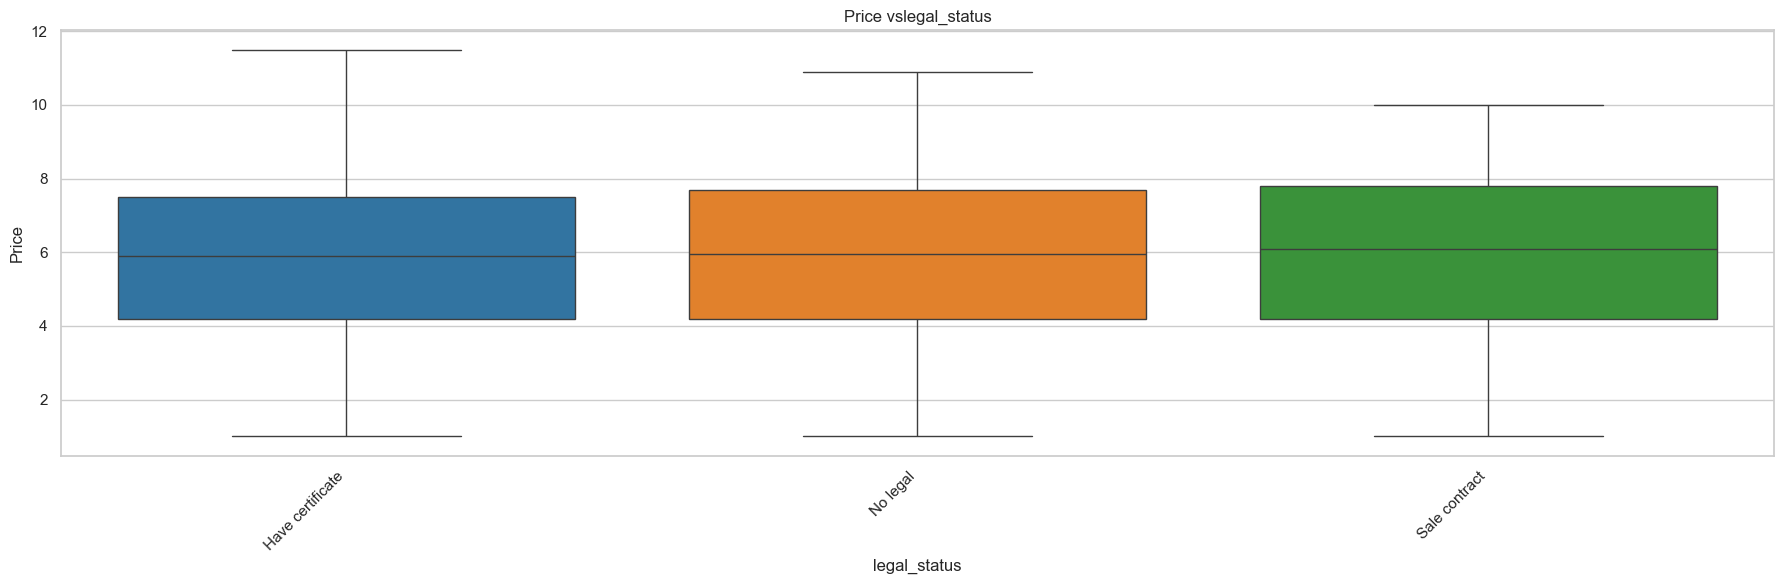

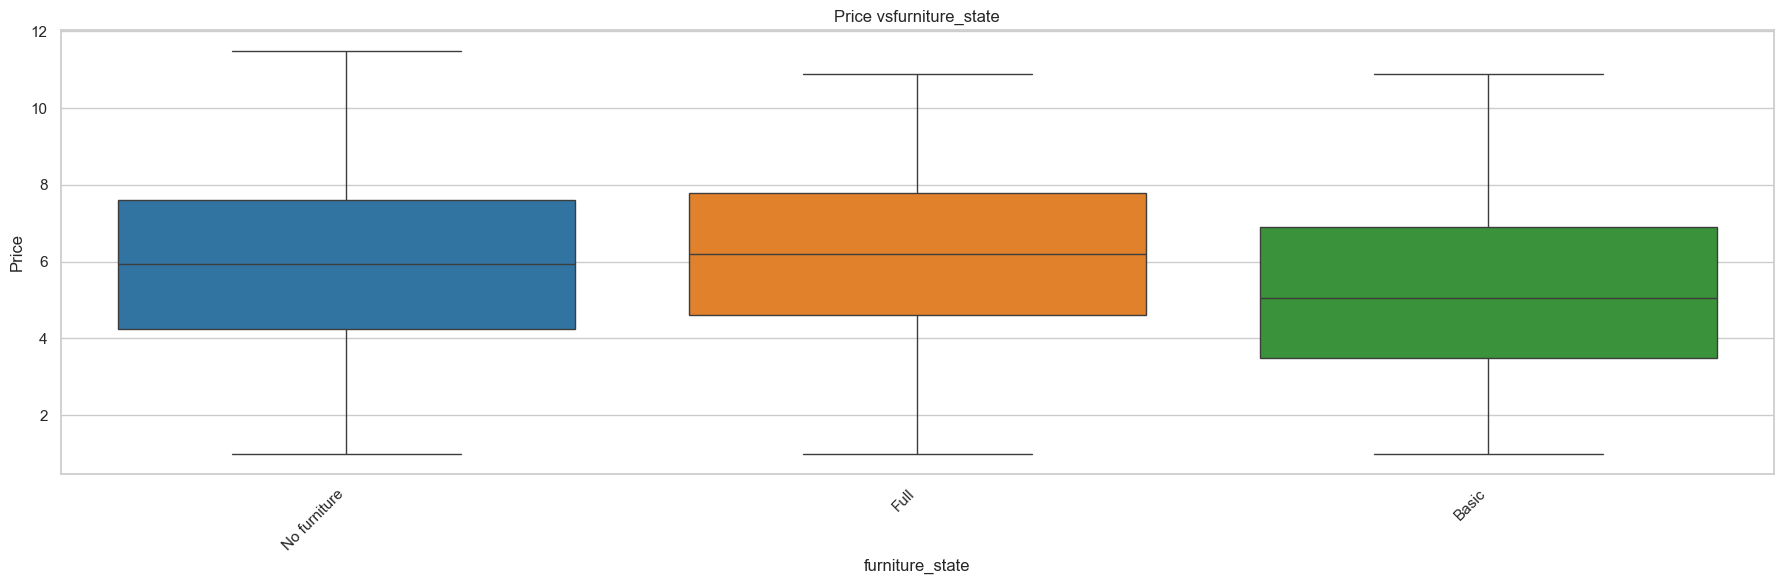

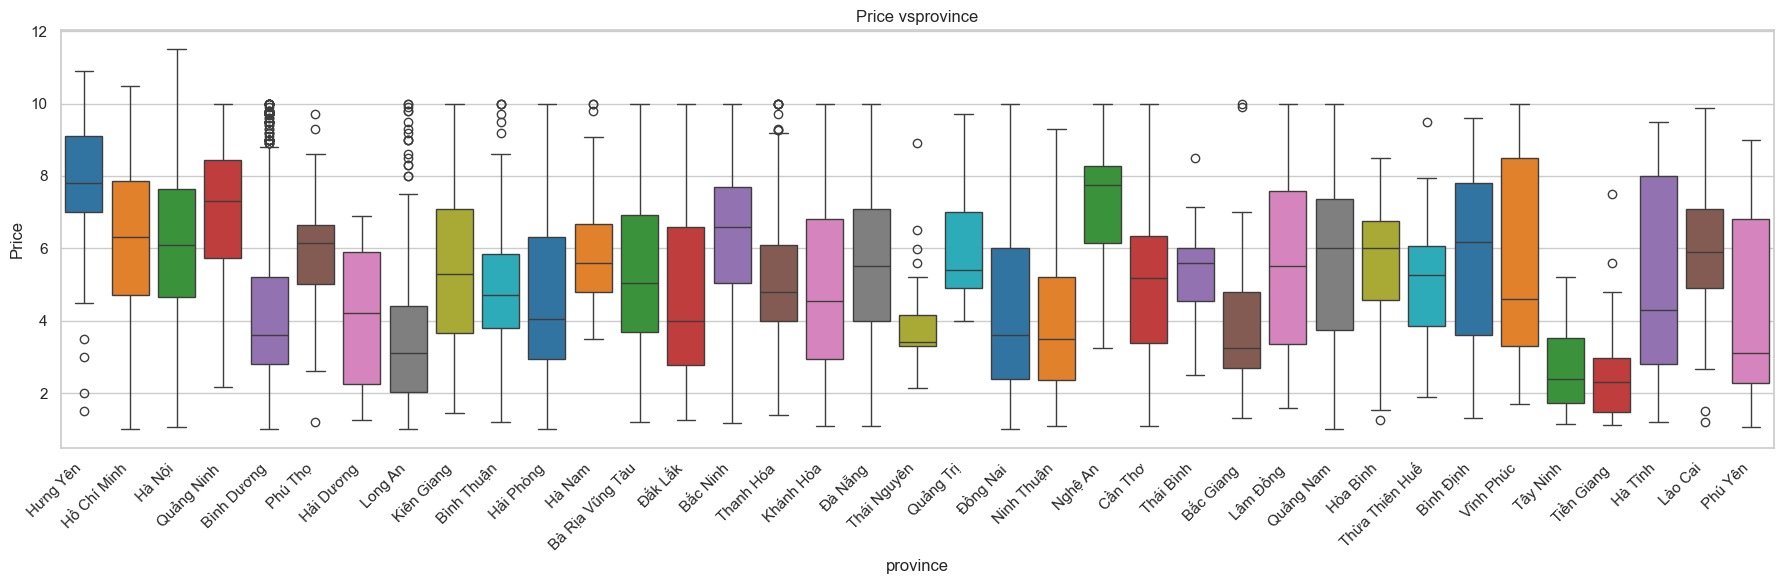

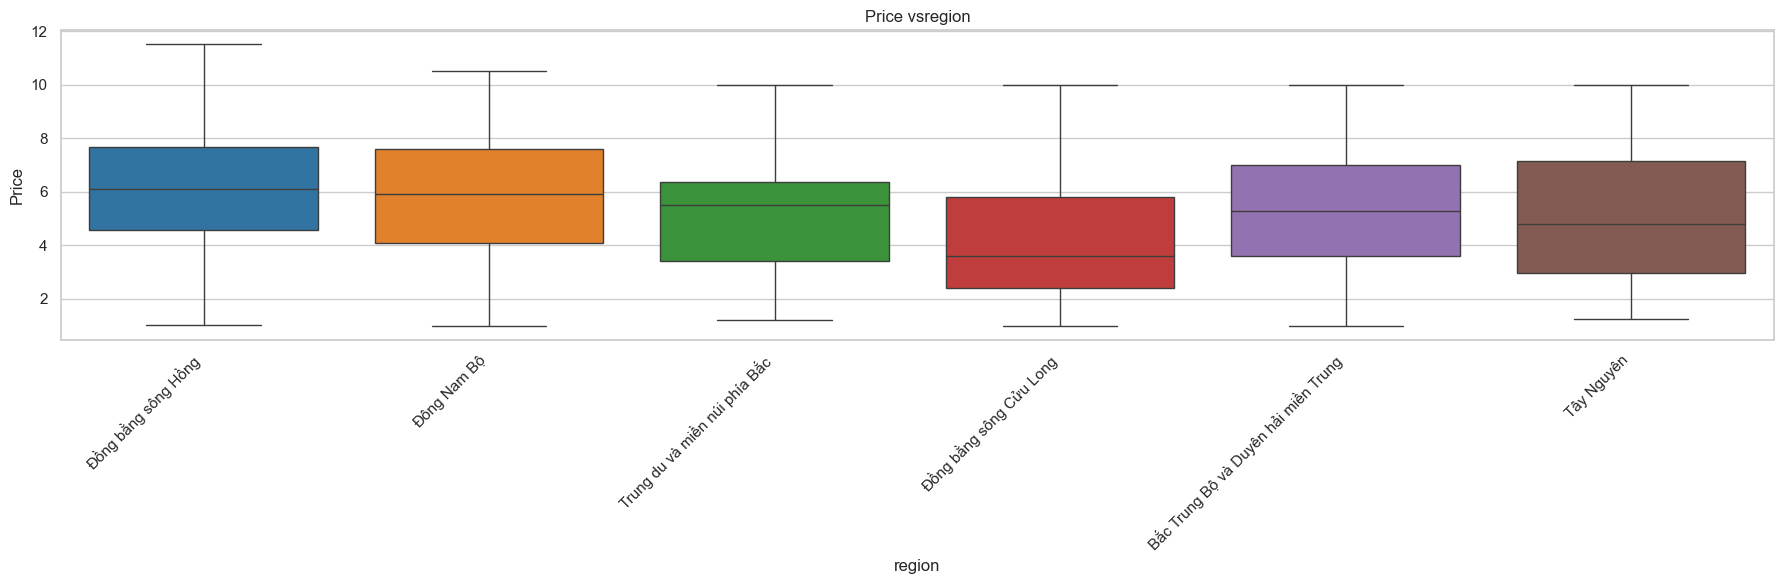

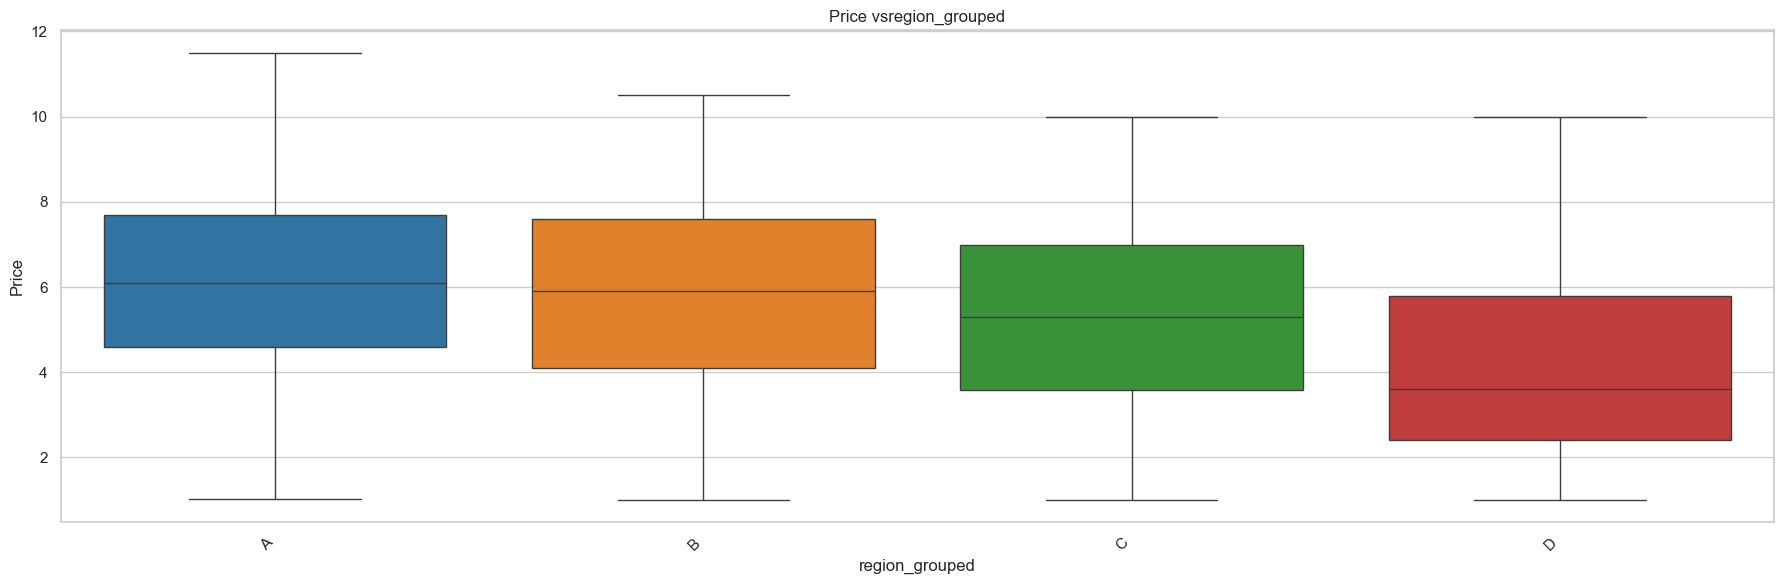

In [118]:
# Create the box plot for Price vs Province
for col in obj_cols:
  plt.figure(figsize=(18, 6))
  sns.boxplot(x=col, y='price', data=data, palette="tab10")
  plt.title('Price vs' + col)
  plt.xlabel(col)
  plt.ylabel('Price')
  plt.xticks(rotation=45, ha='right')  # Rotate the x labels for better readability

  # Show the plot
  plt.tight_layout()
  plt.show()

- Biến province có vẻ là tác động nhiều nhất đến giá nhà
- Ta sử dụng ANOVA test để kiểm tra xem mức độ tác động của các biến lên giá nhà

2    1.000000e-300
4    1.003753e-140
3    6.278549e-139
1    1.515884e-125
0     2.349425e-01
Name: pval, dtype: float64


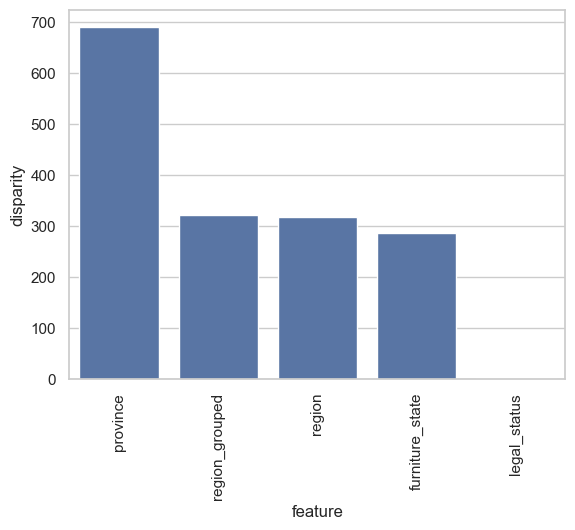

In [119]:
def anova(frame):
    anv = pd.DataFrame()
    anv['feature'] = obj_cols
    pvals = []
    for c in obj_cols:
        samples = []
        for cls in frame[c].unique():
            s = frame[frame[c] == cls]['price'].values
            samples.append(s)
        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)
    anv['pval'] = pvals
    return anv.sort_values('pval')

a = anova(data)
a['pval'] = a['pval'].replace(0, 1e-300)
a['disparity'] = np.log(1./a['pval'].values)
print(a['pval'])
sns.barplot(data=a, x='feature', y='disparity')
x=plt.xticks(rotation=90)

- Ta tính toán disparity dựa trên p_val
- disparity càng lớn thì p_value càng nhỏ thì tác động của biến lên giá nhà càng lớn
- Ở đây ta thấy biến province và region_grouped là 2 biến có tác động đáng kể

### Biến dạng số

#### Correlation

In [120]:
print(data['population_density'].nunique())

37


In [121]:
num_cols = data.select_dtypes(include='number').columns
num_cols

Index(['area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms',
       'price', 'project', 'population', 'population_density',
       'average_area_by_density', 'average_floors_by_density',
       'average_price_by_region_grouped'],
      dtype='object')

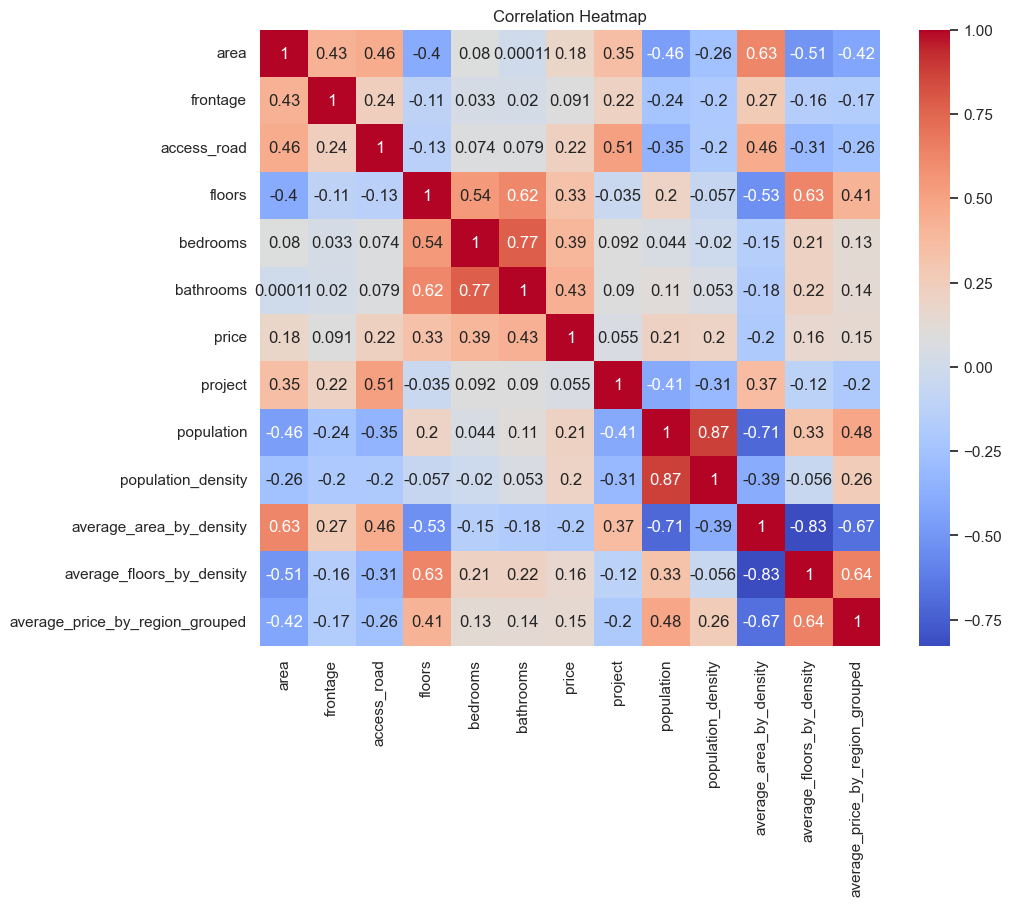

In [122]:
# Vẽ biểu đồ hệ số tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



**Nhận xét về ma trận tương quan:**
- *Diện tích (Area) và giá (Price):* Có mối tương quan dương, tuy không quá mạnh. Điều này có nghĩa là khi diện tích tăng thì giá có xu hướng tăng, nhưng không phải lúc nào cũng đúng và có thể có nhiều yếu tố khác ảnh hưởng đến giá.
- *Số phòng ngủ (Bedrooms) và số phòng tắm (Bathrooms):* Có mối tương quan dương rất mạnh. Điều này hợp lý vì thường thì nhà có nhiều phòng ngủ sẽ đi kèm với nhiều phòng tắm hơn.
- *Số tầng (Floors) và các biến khác:* Số tầng có mối tương quan dương với số phòng ngủ, số phòng tắm và giá. Điều này cho thấy nhà cao tầng thường có nhiều phòng hơn và giá cao hơn.
- *Mặt tiền (Frontage) và các biến khác:* Mặt tiền có mối tương quan yếu với các biến khác.
- *Đường vào (Access Road) và các biến khác:* Tương tự như mặt tiền, đường vào cũng có mối tương quan yếu với các biến khác.
- *Dân số (population) và các biến khác:* Dân số có tương quan dương không quá mạnh với Price, cho thấy nơi có dân số đông cũng sẽ làm tăng giá nhà. Tương quan âm khá cao với area cho thấy nơi có dân cư càng thấp diện tích càng lớn. Tương quan cao với population_dentsity cho thấy nơi có dân số đông thì mật độ dân số cũng sẽ cao. Có tương quan yếu với các biến còn lại
- *Mật độ dân số (population_density) và các biến khác:* Có tương quan dương yếu với Price, cho thấy nơi có mật độ dân số cao cũng sẽ làm tăng giá nhà. Trừ population, mật độ dân số có mối tương quan thấp với các biến còn lại.
- *Dự án (project) và các biến khác:* Dự án có tương quan khá cao với access_road và không quá mạnh với area, cho thấy dự án được xây dựng ở những nơi có đường vào rọng hơn và dự án sẽ có diện tích lớn hơn so với nhà không là dự án. Có tương quan yếu với các biến còn lại.

Ta vẽ biểu đồ cột để thể hiện rõ hơn mối quan hệ tuyến tính giữa các biến với giá nhà

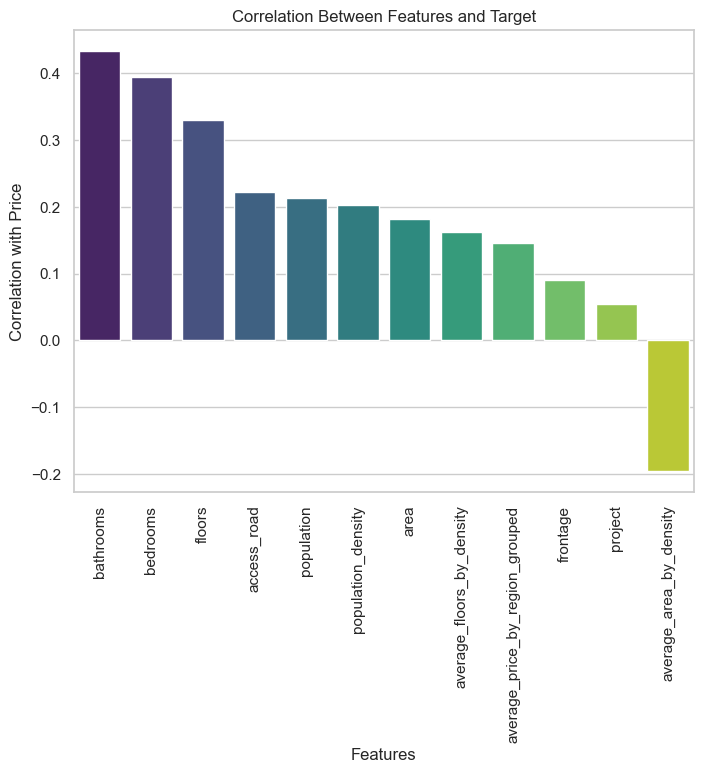

In [123]:
# Tương quan giữa các biến với cột price
corr_matrix = data[num_cols].corr()
plt.figure(figsize=(8, 6))
target_corr = corr_matrix['price'].sort_values(ascending=False).drop('price')
sns.barplot(x=target_corr.index, y=target_corr.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Correlation with Price')
plt.title("Correlation Between Features and Target")
plt.show()

- Biến có hệ số tương quan với giá nhà cao nhất là bathrooms(hơn 0.4)
- Biến có hệ so61 tương quan với giá nhà thấp nhất là frontage (dưới 0.1)
- Tất cã các biến đều có hệ số tương quan thập với biến mục tiêu. Điều này cho thấy mối quan hệ tuyến tính yếu giữa biến giải thích và biến mục tiêu.

####Mutual information

- Ta đã thấy trong dữ liệu này, mối quan hệ tuyến tính giữa các biến với giá trị dự đoán là không cao. Tuy nhiên vẫn có thể tồn tại mối quan hệ phi tuyến
- Sử dụng mutual information để khám phá các mối quan hệ này

 **Ý tưởng cơ bản của Mutual Information**

Mutual Information (MI) là thước đo sự phụ thuộc lẫn nhau giữa hai biến ngẫu nhiên \(X\) và \(Y\). MI cho biết lượng thông tin mà một biến \(X\) cung cấp về biến \(Y\), và ngược lại. Nếu \(X\) và \(Y\) độc lập, Mutual Information giữa chúng sẽ bằng 0.

Công thức định nghĩa MI như sau:

$$
I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \cdot \log\left(\frac{p(x, y)}{p(x) \cdot p(y)}\right)
$$

**Ý nghĩa của từng thành phần**:
1. \(I(X; Y)\): Lượng thông tin chung giữa hai biến \(X\) và \(Y\).
2. \(p(x, y)\): Phân phối xác suất chung của \(X\) và \(Y\), mô tả xác suất xảy ra đồng thời của cả hai biến.
3. \(p(x)\): Phân phối xác suất biên của \(X\), mô tả xác suất xảy ra của biến \(X\) bất kể \(Y\).
4. \(p(y)\): Phân phối xác suất biên của \(Y\), mô tả xác suất xảy ra của biến \(Y\) bất kể \(X\).
5. \(\log\left(\frac{p(x, y)}{p(x) \cdot p(y)}\right)\): Đo lường mức độ phụ thuộc giữa \(X\) và \(Y\) tại các giá trị cụ thể của \(x\) và \(y\).

**Ý tưởng chính**:
- Nếu \(X\) và \(Y\) **độc lập**, phân phối chung \(p(x, y)\) sẽ bằng tích các phân phối biên $(p(x) \cdot p(y))$, và MI bằng 0.
- Nếu \(X\) và \(Y\) **phụ thuộc**, MI sẽ lớn hơn 0, và giá trị càng cao khi mối liên hệ giữa \(X\) và \(Y\) càng mạnh.

**Ứng dụng của MI**:
- Lựa chọn đặc trưng (Feature Selection) trong Machine Learning.
- Đo lường mức độ liên quan giữa các biến trong phân tích dữ liệu.
- Xác định các mối quan hệ phi tuyến tính giữa các biến.



In [124]:
def make_mi_scores(x, y):
    smi_scores = {}
    for col in x.columns:
        # Loại bỏ NaN chỉ trong cột hiện tại và biến target
        valid_data = pd.concat([x[col], y], axis=1).dropna()

        # Tính Standardized Mutual Information (SMI)
        smi = normalized_mutual_info_score(
            valid_data[y.name],  # Biến target
            valid_data[col],     # Biến hiện tại
        )
        smi_scores[col] = smi

    # Trả về kết quả SMI Scores dưới dạng Series
    smi_scores = pd.Series(smi_scores, name="SMI Scores").sort_values(ascending=False)
    return smi_scores

In [125]:
x = data[num_cols].copy()
y = x.pop('price')
# Tính và in MI Scores
print(make_mi_scores(x, y))

area                               0.231337
frontage                           0.147470
access_road                        0.112502
population                         0.072601
population_density                 0.072601
average_area_by_density            0.072601
average_floors_by_density          0.072271
bathrooms                          0.064282
bedrooms                           0.055941
floors                             0.047917
average_price_by_region_grouped    0.021469
project                            0.009656
Name: SMI Scores, dtype: float64


#### Biến rời rạc

In [126]:
discrete_cols = ["bathrooms", "bedrooms", "floors"]
discrete_cols

['bathrooms', 'bedrooms', 'floors']

In [127]:
for col in discrete_cols:
    print("{} has {} unique values.".format(col,data[col].unique()))

bathrooms has [nan  3.  4.  5.  6.  2.  1.  9.  8.  7.] unique values.
bedrooms has [       nan 1.09861229 1.60943791 1.94591015 1.79175947 2.07944154
 1.38629436 0.69314718 2.19722458 2.30258509] unique values.
floors has [ 4.  5.  2. nan  3.  1.  6.  7. 10.  8.  9.] unique values.


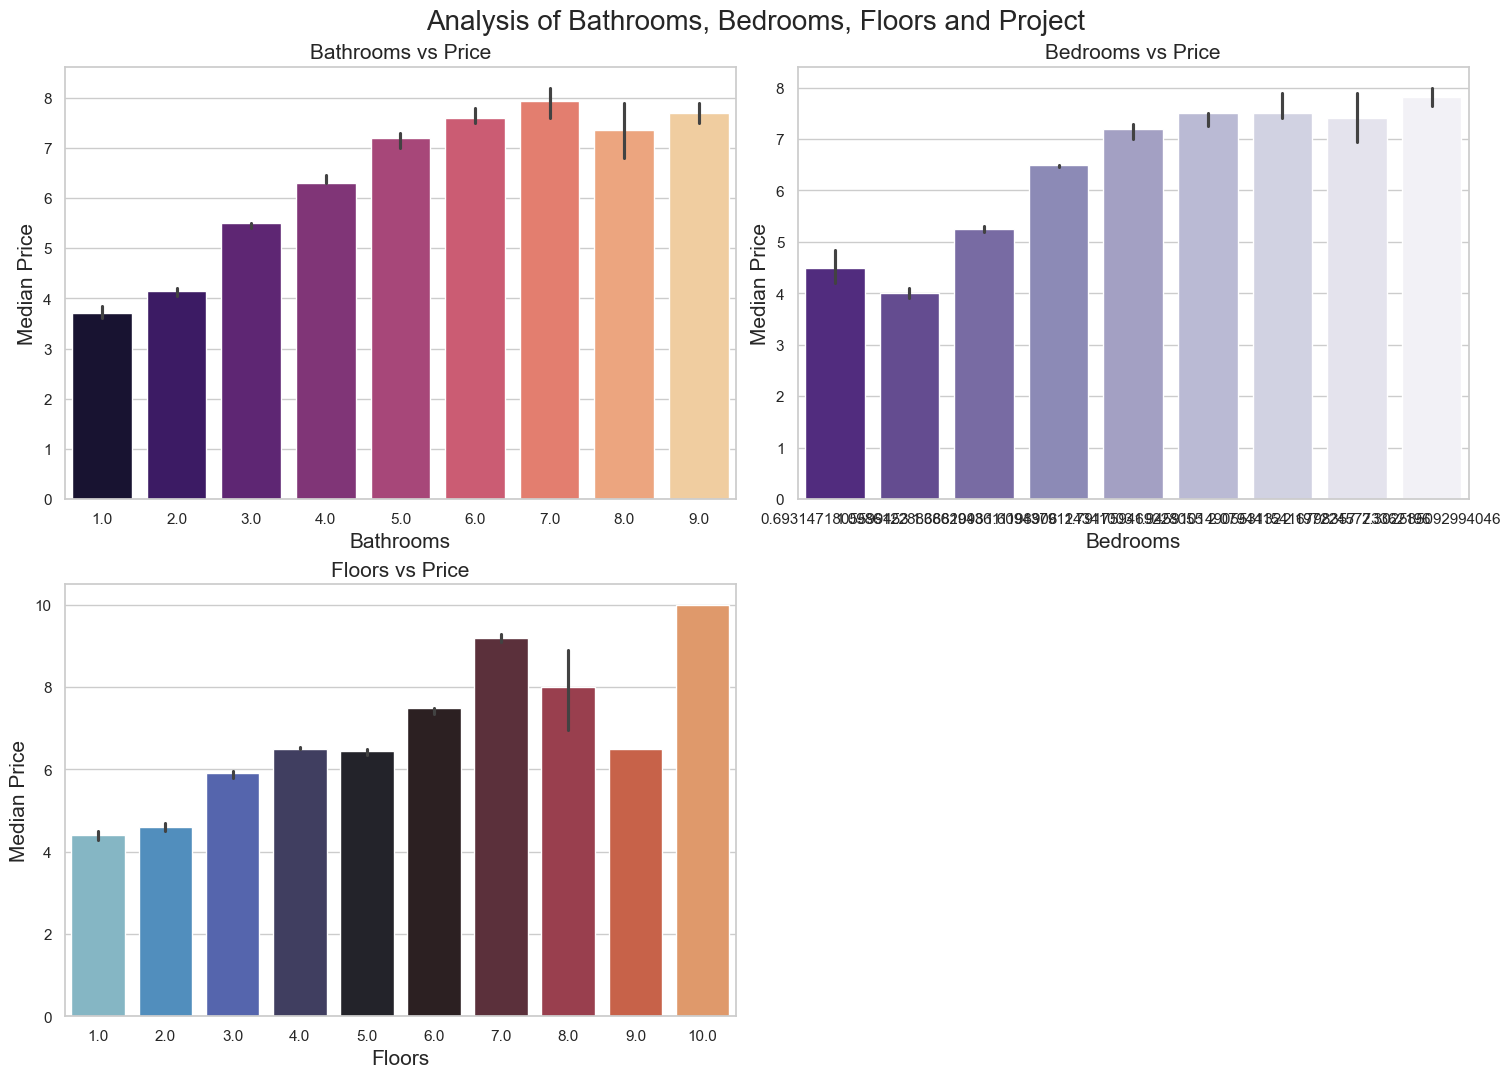

In [128]:
fig = plt.figure(constrained_layout=True, figsize=(15, 15))
gs = GridSpec(3, 2, figure=fig)  # Lưới 3 hàng x 2 cột

# Biểu đồ 1: bathrooms vs price
plt.subplot(gs[0, 0])
sns.barplot(data=data, x="bathrooms", y="price", estimator=median, palette='magma')
plt.xlabel("Bathrooms", fontsize=15)
plt.ylabel("Median Price", fontsize=15)
plt.title("Bathrooms vs Price", fontsize=15)

# Biểu đồ 2: bedrooms vs price
plt.subplot(gs[0, 1])
sns.barplot(data=data, x="bedrooms", y="price", estimator=median, palette='Purples_r')
plt.xlabel("Bedrooms", fontsize=15)
plt.ylabel("Median Price", fontsize=15)
plt.title("Bedrooms vs Price", fontsize=15)

# Biểu đồ 3: floors vs price
plt.subplot(gs[1, 0])
sns.barplot(data=data, x="floors", y="price", estimator=median, palette='icefire')
plt.xlabel("Floors", fontsize=15)
plt.ylabel("Median Price", fontsize=15)
plt.title("Floors vs Price", fontsize=15)

# Tiêu đề chung
plt.suptitle("Analysis of Bathrooms, Bedrooms, Floors and Project", fontsize=20)
plt.show()


- Ta có thể thấy, khi floors , bathrooms. bedrooms tăng lên thì giá nhà có xu hướng tăng theo. Điều này là hợp lý trong thực tế.

#### Biến liên tục

In [129]:
continious_cols = ["area", "frontage", "access_road"]
continious_cols

['area', 'frontage', 'access_road']

In [130]:
data[continious_cols].describe()

,area,frontage,access_road
count,30113.000000,18584.000000,16863.000000
mean,4.092198,1.771570,1.977446
std,0.506579,0.318992,0.581333
min,1.410987,0.693147,0.693147
25%,3.713572,1.609438,1.609438
50%,4.043051,1.704748,1.945910
75%,4.394449,1.791759,2.397895
max,6.390241,4.356709,4.454347


- Biến area: có khoảng giá trị từ 3.1 (m2) đến 595 (m2). Trung bình là 68.4 (m2)
- Biến frontage: có khoảng giá trị từ 4.34 (m2) đến  77(m2). Trung bình là 5.3 (m2)
- Biến access_road: có khoảng giá trị từ 1 (m2) đến 85 (m2). Trung bình là 7.8 (m2)

=> Ta có thể thấy đa số các biến đều lệch phải. Vẽ biểu đồ để thể hiện điều đó

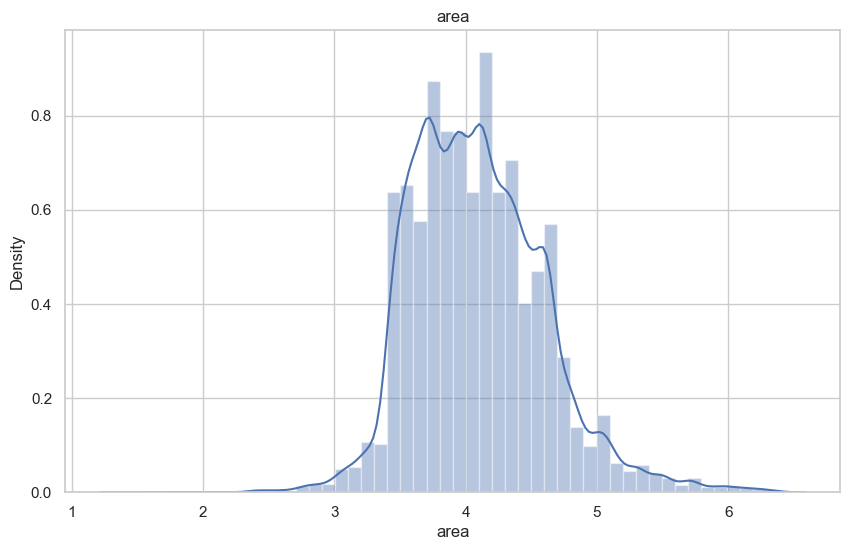

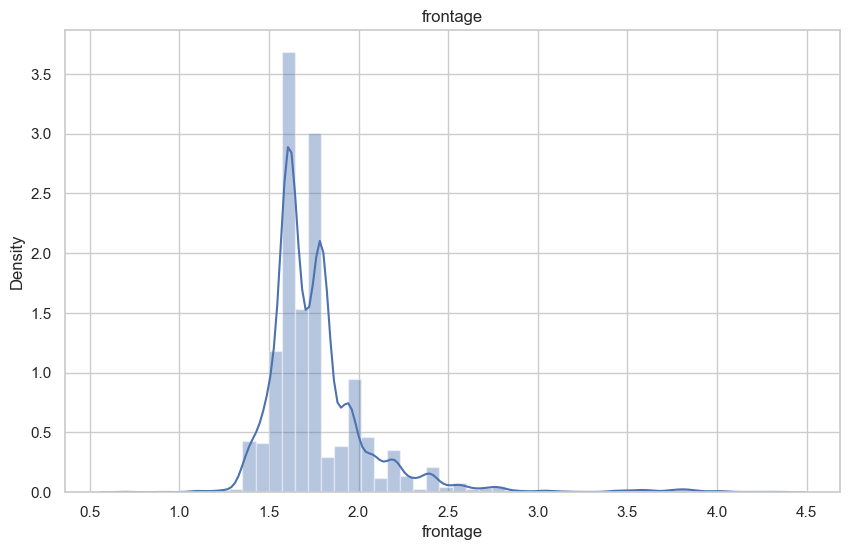

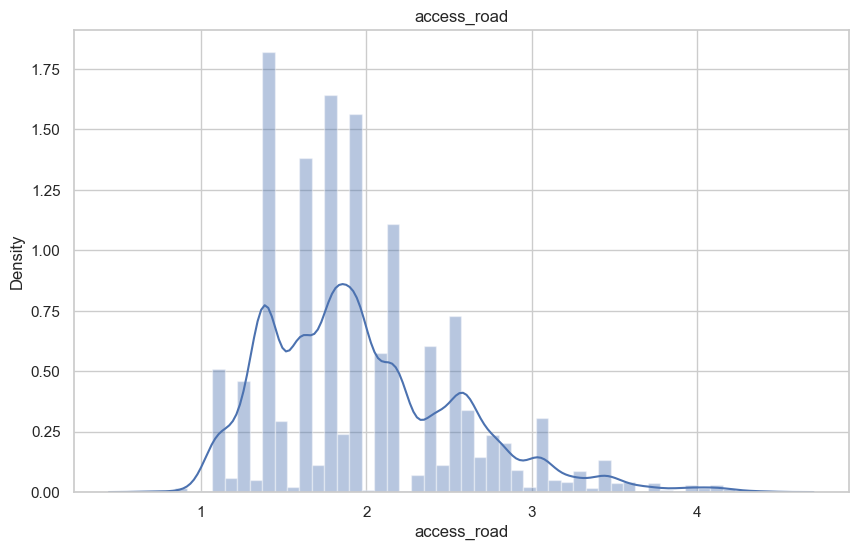

In [131]:
for col in continious_cols:
    plt.figure(figsize=(10, 6))
    plt.title(col)
    sns.distplot(data[col], kde=True)


- Dữ liệu đã đỡ lệch hơn khi áp dụng log transformation

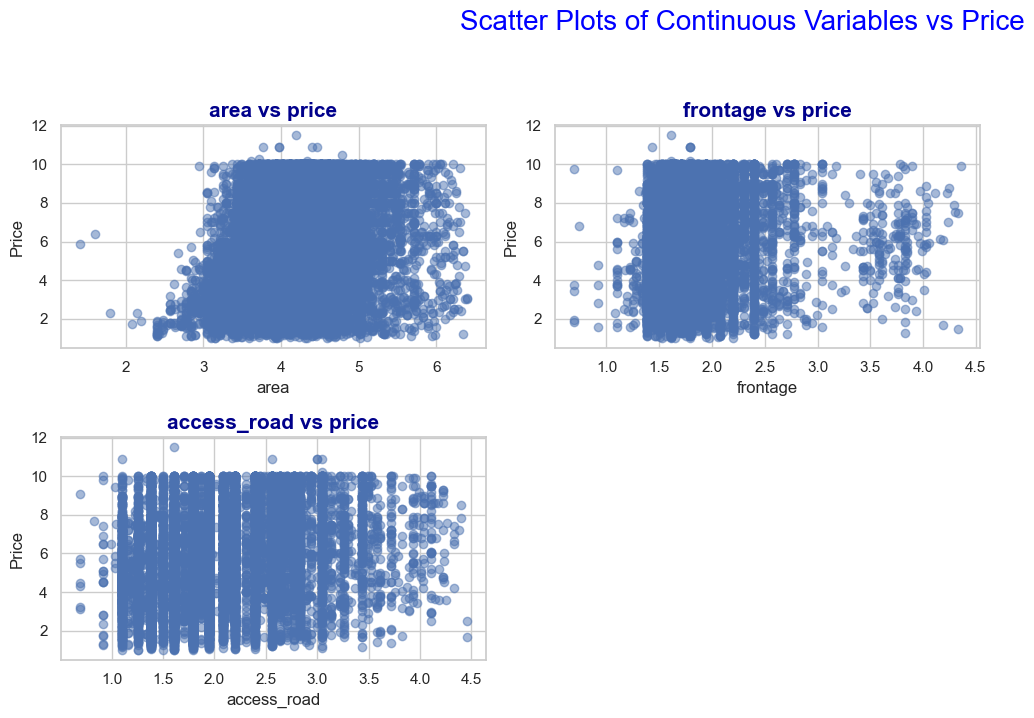

In [132]:
# Tạo lưới với GridSpec
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3,3, figure=fig)

# Vẽ từng biểu đồ trong lưới
for i, col in enumerate(continious_cols):
    ax = fig.add_subplot(gs[i // 2, i % 2])  # Chỉ định vị trí biểu đồ trong lưới
    ax.scatter(data[col], data['price'], alpha=0.5)
    ax.set_title(f'{col} vs price', fontsize=15, color='darkblue', fontweight="bold")  # Đổi màu tiêu đề
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Price', fontsize=12)

# Tiêu đề chung
fig.suptitle("Scatter Plots of Continuous Variables vs Price", fontsize=20, color='blue')  # Đổi màu tiêu đề chung
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Điều chỉnh khoảng cách giữa các biểu đồ và tiêu đề
plt.show()

- Gần như không có mối quan hệ nào giữa các biến với giá nhà

In [133]:
fig = make_subplots(rows=1, cols=2)

fig.add_trace(go.Histogram(x=data['price']),row=1,col=1)
fig.add_trace(go.Box(y=data['price'],boxpoints='all',line_color='orange'),row=1,col=2)

fig.update_layout(height=500, showlegend=False,title_text="Sale Price Distribution and Box Plot")

- Giá nhà có phân phối tương đối giống phân pbối chuẩn
- Những căn nhà hơn 10 tỷ trong bộ dữ liệu này khá ít

## Feature Engineering

In [134]:
# Bỏ đi 1 số cột không cần thiết
useless_cols = ['province', 'region', 'region_grouped']
data.drop(columns=useless_cols, inplace=True)

In [135]:
data.head()

,area,frontage,access_road,floors,bedrooms,bathrooms,legal_status,furniture_state,price,project,population,population_density,average_area_by_density,average_floors_by_density,average_price_by_region_grouped
0,4.442651,NaN,NaN,4.0,NaN,NaN,Have certificate,No furniture,8.60,1,1290850,1388,4.276570,4.858553,6.125688
1,4.110874,NaN,NaN,5.0,NaN,NaN,No legal,No furniture,7.50,1,1290850,1388,4.276570,4.858553,6.125688
2,4.510860,1.94591,2.639057,5.0,NaN,NaN,Sale contract,No furniture,8.90,1,1290850,1388,4.276570,4.858553,6.125688
3,4.007333,NaN,1.504077,2.0,1.098612,3.0,Have certificate,Full,5.35,0,9389720,4481,4.204712,2.883245,5.845045
4,4.532599,NaN,NaN,2.0,1.609438,4.0,Have certificate,Full,6.90,0,9389720,4481,4.204712,2.883245,5.845045


In [136]:
from sklearn.model_selection import train_test_split

### Bỏ đi ngoại lai

In [137]:
# Các cột cần xét ngoại lai
outlier_cols = ['area', 'frontage', 'access_road']

In [138]:
# In kích thước dữ liệu trước khi lọc outliers
print(f"Before filtering: {data.shape}")

# Hàm loại bỏ outliers sử dụng phương pháp IQR
def remove_outlier_IQR(df, series):
    Q1 = df[series].quantile(0.25)
    Q3 = df[series].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df[~((df[series] < (Q1 - 1.5 * IQR)) | (df[series] > (Q3 + 1.5 * IQR)))]
    return df_filtered

# Lọc outliers cho từng cột số (trừ cột cần loại trừ)
for col in outlier_cols:
    data = remove_outlier_IQR(data, col)

# Reset index sau khi lọc
data.reset_index(inplace=True, drop=True)

# In kích thước dữ liệu sau khi lọc outliers
print(f"After filtering: {data.shape}")

Before filtering: (30113, 15)
After filtering: (27175, 15)


In [139]:
data.head(5)

,area,frontage,access_road,floors,bedrooms,bathrooms,legal_status,furniture_state,price,project,population,population_density,average_area_by_density,average_floors_by_density,average_price_by_region_grouped
0,4.442651,NaN,NaN,4.0,NaN,NaN,Have certificate,No furniture,8.60,1,1290850,1388,4.276570,4.858553,6.125688
1,4.110874,NaN,NaN,5.0,NaN,NaN,No legal,No furniture,7.50,1,1290850,1388,4.276570,4.858553,6.125688
2,4.510860,1.94591,2.639057,5.0,NaN,NaN,Sale contract,No furniture,8.90,1,1290850,1388,4.276570,4.858553,6.125688
3,4.007333,NaN,1.504077,2.0,1.098612,3.0,Have certificate,Full,5.35,0,9389720,4481,4.204712,2.883245,5.845045
4,4.532599,NaN,NaN,2.0,1.609438,4.0,Have certificate,Full,6.90,0,9389720,4481,4.204712,2.883245,5.845045


### Tách dữ liệu

- Đảm bảo tách dữ liệu trước các bước như imputation hay encoding để tránh việc dữ liệu của bộ test bị rò rỉ vào bộ train

In [140]:
target = "price"
x = data.drop([target], axis=1)
y = data[target]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


- Tách dữ liệu thành 2 bộ train và test với tỉ lệ
  - Train: 80%
  - Test: 20%
- Dùng parameter **stratify=x["province"]** để đảm bảo các tỉnh được phân bố đều cả trong bộ train và bộ test

In [141]:
print(f"Train: {x_train.shape}")
print(f"Test: {x_test.shape}")

Train: (21740, 14)
Test: (5435, 14)


### Điền khuyết

- Sử dụng thư viện  miceforest để điền khuyết
- **Ý tưởng**:
  - Khởi ta
  - Sẽ dùng mô hình random forest để điền các giá trị bị thiếu
  - Kết quả dự đoán sẽ được chọn từ KNN giá trị thực tế gần nhất với giá trị dự đoán

In [142]:
from sklearn.experimental import enable_iterative_imputer  # Kích hoạt IterativeImputer
from sklearn.impute import IterativeImputer

In [ ]:
x_train.isnull().sum()

area                     0
frontage              7989
access_road           9040
floors                2081
bedrooms              3483
bathrooms             4741
legal_status             0
furniture_state          0
project                  0
population               0
population_density       0
dtype: int64

In [143]:
dcr_imputer = IterativeImputer(
    estimator=LinearRegression(),
    max_iter=10,
    tol=1e-10,
    initial_strategy="most_frequent",
    random_state=42
)

cont_imputer = IterativeImputer(
    estimator= DecisionTreeRegressor(),
    max_iter=10,
    tol=1e-10,
    initial_strategy="mean",
    random_state=42
)

- Các cột bathrooms, bedrooms và floors là các biến rời rạc và có hệ số tương quan với nhau khá cao. Do đó ta dùng mô hình LinearRegression để phát huy mối quan hệ tuyến tính
- Các cột area, frontage và access_road các biến liên tục nhưng không tương quan cao với các biến còn lại. Do đó ta chọn 1 mô hình phi tuyến là Decision Tree

In [144]:
print(x_train.isnull().sum())

area                                   0
frontage                            8958
access_road                        10015
floors                              2434
bedrooms                            3682
bathrooms                           5112
legal_status                           0
furniture_state                        0
project                                0
population                             0
population_density                     0
average_area_by_density                0
average_floors_by_density              0
average_price_by_region_grouped        0
dtype: int64


In [ ]:
data.head(5)

,area,frontage,access_road,floors,bedrooms,bathrooms,legal_status,furniture_state,price,project,population,population_density,average_area_by_density,average_floors_by_density,average_price_by_region_grouped
0,4.442651,NaN,NaN,4.0,NaN,NaN,Have certificate,No furniture,8.60,1,1290850,1388,4.276570,4.858553,6.125688
1,4.110874,NaN,NaN,5.0,NaN,NaN,No legal,No furniture,7.50,1,1290850,1388,4.276570,4.858553,6.125688
2,4.510860,1.94591,2.639057,5.0,NaN,NaN,Sale contract,No furniture,8.90,1,1290850,1388,4.276570,4.858553,6.125688
3,4.007333,NaN,1.504077,2.0,1.098612,3.0,Have certificate,Full,5.35,0,9389720,4481,4.204712,2.883245,5.845045
4,4.532599,NaN,NaN,2.0,1.609438,4.0,Have certificate,Full,6.90,0,9389720,4481,4.204712,2.883245,5.845045


- Ta tạo lớp FeatureEngineering kế thừa BaseEstimator, TransformerMixin để có thể đưa vào trong Pipeline

### Mã hoá

- Ta cần mã hoá các cột kiểu object về dạng số để phù hợp với mô hình

In [145]:
# Tạo pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Phân loại cột
num_dcr_cols = ['bathrooms', 'bedrooms', 'floors', 'population', 'population_density', 'average_price_by_region_grouped', 'average_floors_by_density']
num_cont_cols = ['area', 'frontage', 'access_road','project']
cat_nom_cols = ['legal_status']
cat_ord_cols = ['furniture_state']
cat_ord = ["Full", "Basic", "No furniture"]

# Cột số với giá trị rời rạc
num_dcr_transformer = Pipeline(steps=[
    ('imputer', dcr_imputer),
    ('scaler', StandardScaler())
])

# Cột số với giá trị liên tục
num_cont_transformer = Pipeline(steps=[
    ('imputer', cont_imputer),
    ('scaler', StandardScaler())
])

# Cột cat với loại nominal
cat_nom_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Cột cat với lại ordinal
cat_ord_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=[cat_ord]))
])
# Tạo ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_nom', cat_nom_transformer, cat_nom_cols),
        ('cat_ord', cat_ord_transformer, cat_ord_cols),
        ('num_dcr', num_dcr_transformer, num_dcr_cols),
        ('num_cont', num_cont_transformer, num_cont_cols),
    ])


## Mô hình dự đoán

- Ta thử với 2 mô hình LinearRegression và ExtraTree

### LINEAR REGRESSION

In [ ]:
print(type(x_train))
print("Shape of x_train:", x_train.shape)
print(x_train.head())

<class 'pandas.core.frame.DataFrame'>
Shape of x_train: (21740, 14)
           area  frontage  access_road  floors  bedrooms  bathrooms  \
13400  4.025352       NaN          NaN     4.0  1.609438        4.0   
1206   3.806662       NaN          NaN     5.0  1.609438        6.0   
5687   4.262680  1.589235     3.044522     2.0  1.386294        3.0   
10902  3.713572  1.791759     1.386294     2.0  1.098612        1.0   
22470  4.060443  1.609438     2.197225     5.0       NaN        NaN   

           legal_status furniture_state  project  population  \
13400  Have certificate            Full        0     9389720   
1206   Have certificate           Basic        0     8435650   
5687   Have certificate            Full        0     1178700   
10902  Have certificate            Full        0     8435650   
22470  Have certificate    No furniture        0     9389720   

       population_density  average_area_by_density  average_floors_by_density  \
13400                4481              

In [146]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
# Pipeline cho mô hình
pipeline_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('linear_reg', LinearRegression())
    ]
)
param_lr = {
    'linear_reg__fit_intercept': [True, False],  # Thử với fit_intercept True và False
}

grid_model_lr = GridSearchCV(pipeline_lr, param_lr, cv=5, scoring='neg_mean_squared_error')

# Huấn luyện mô hình
grid_model_lr.fit(x_train, y_train)

print("Best params: ", grid_model_lr.best_params_)
print("Best score: ", grid_model_lr.best_score_)

Best params:  {'linear_reg__fit_intercept': True}
Best score:  -2.8659684404592882


In [147]:
lr = grid_model_lr.best_estimator_
y_pred_lr = lr.predict(x_test)

In [148]:
r2_lr = r2_score(y_test, y_pred_lr)
print('R2: ', r2_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
print('MSE: ', mse_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
print('RMSE:', rmse_lr)

R2:  0.3925738095815726
MSE:  2.909494100650008
RMSE: 1.7057239227524505


### Extra Tree

In [149]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

pipeline_etr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('etr', ExtraTreesRegressor(random_state=42))
    ]
)
param_etr = {
    'etr__n_estimators': [100, 200, 300],
    'etr__max_depth': [10, 20, 30],
    'etr__min_samples_split': [2, 5, 10],
    'etr__min_samples_leaf': [1, 2, 4]
}

# Huấn luyện mô hình
grid_model_etr = GridSearchCV(pipeline_etr, param_grid=param_etr, cv=3, n_jobs=-1)
grid_model_etr.fit(x_train, y_train)
print("Best params: ", grid_model_etr.best_params_)
print("Best score: ", grid_model_etr.best_score_)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion 

Best params:  {'etr__max_depth': 20, 'etr__min_samples_leaf': 4, 'etr__min_samples_split': 10, 'etr__n_estimators': 300}
Best score:  0.5040509029721033


In [152]:
etr = grid_model_etr.best_estimator_
y_pred_etr = etr.predict(x_test)

In [ ]:
import pickle

# Lưu mô hình
with open('etr_model.pkl', 'wb') as file:
    pickle.dump(etr, file)


In [153]:
r2_etr = r2_score(y_test, y_pred_etr)
print('R2: ', r2_etr)
mse_etr = mean_squared_error(y_test, y_pred_etr)
print('MSE: ', mse_etr)
rmse_etr = np.sqrt(mse_etr)
print('RMSE:', rmse_etr)

R2:  0.5160911521485355
MSE:  2.3178617588193244
RMSE: 1.5224525473128299


- Bộ tham số mặc định là {'etr__max_depth': None, 'etr__min_samples_leaf': 1, 'etr__min_samples_split': 2, 'etr__n_estimators': 100}
- Sau khi tuning params thì ta có bộ param tốt nhất là {'etr__max_depth': 20, 'etr__min_samples_leaf': 4, 'etr__min_samples_split': 10, 'etr__n_estimators': 300}

- Ta có thể thấy bộ param mới giúp giảm khả năng mô hình bị overfitting khi xác định các tham số như min_samples_leaf, min_samples_split,...
- Ngoài ra, việc tăng thêm số lượng Estimator giúp mô hình cây dự đoán chính xác hơn

In [154]:
models = ['Linear Regression', 'Extra Tree']
mse_scores = [mse_lr, mse_etr]
rmse_scores = [rmse_lr, rmse_etr]
r2_scores = [r2_lr, r2_etr]

df = pd.DataFrame({'Model': models, 'MSE': mse_scores,'RMSE': rmse_scores, 'R2': r2_scores})
print(df)

               Model       MSE      RMSE        R2
0  Linear Regression  2.909494  1.705724  0.392574
1         Extra Tree  2.317862  1.522453  0.516091


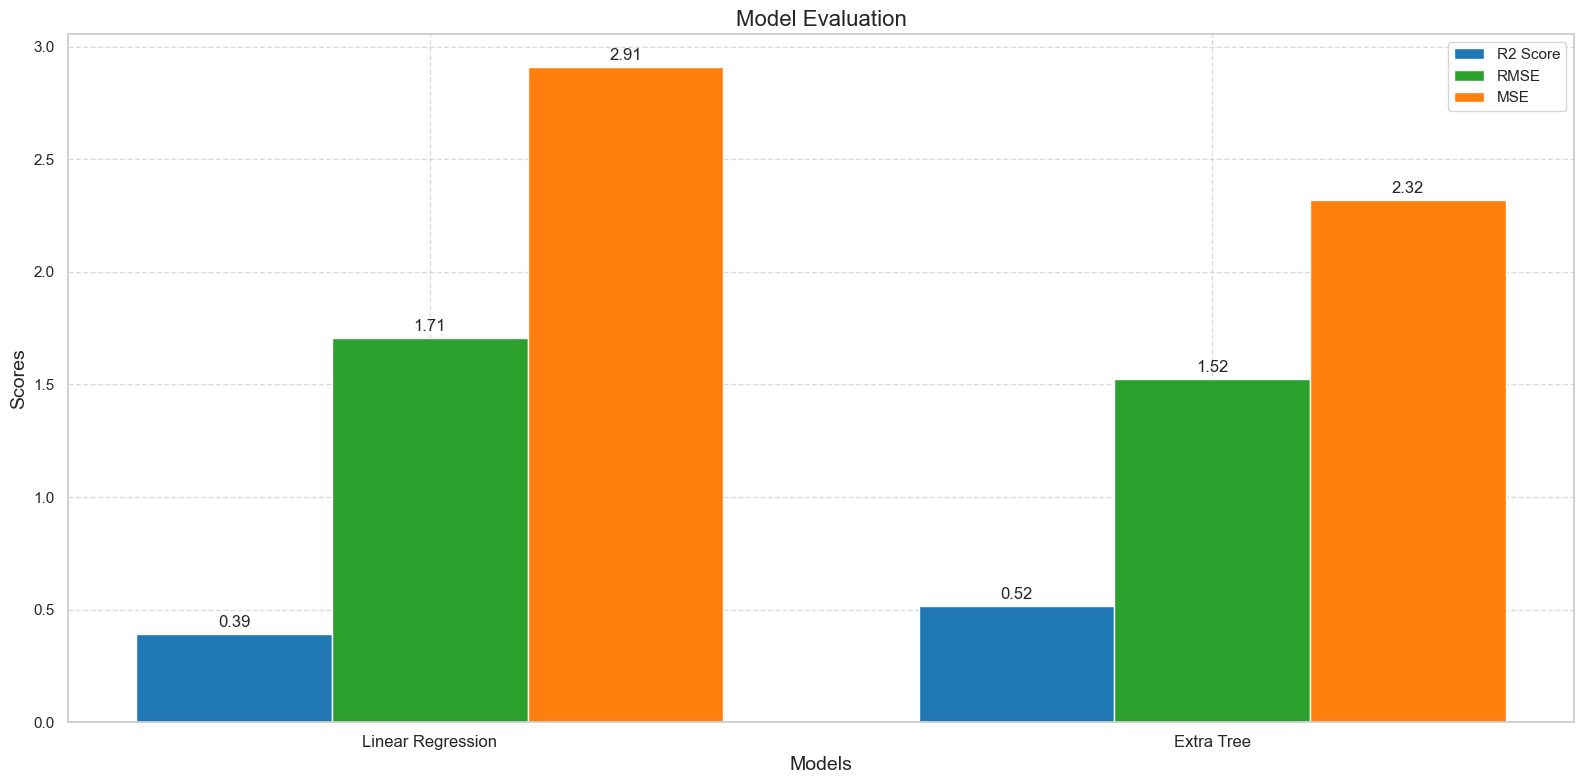

In [155]:
# Vẽ biểu đồ
x = np.arange(len(models))  # Vị trí các cột trên trục x
width = 0.25  # Độ rộng của mỗi cột

fig, ax = plt.subplots(figsize=(16, 8))

# Vẽ các cột cho từng chỉ số
rects1 = ax.bar(x - width, r2_scores, width, label='R2 Score', color='#1f77b4')
rects2 = ax.bar(x, rmse_scores, width, label='RMSE', color='#2ca02c')
rects3 = ax.bar(x + width, mse_scores, width, label='MSE', color='#ff7f0e')

# Đặt tên cho các trục và tiêu đề
ax.set_ylabel('Scores', fontsize=14)
ax.set_title('Model Evaluation', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_xlabel('Models', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

# Hiển thị giá trị trên mỗi cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{round(height, 2)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=12)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

- Sau khi thử nghiệm trên 2 mô hình LinearRegression (tuyến tính) và ExtraTree (phi tuyến) thì ta thấy mô hình ExtraTree hoạt động tốt hơn. Điều này là hợp lý.

- Vì dữ liệu có hệ số tương quan thấp với biến target va mô hình ExtreTree là mô hình mạnh hơn

## API

folder chưa code API: python.zip

deyploy model bằng flask api trên instance ec2 của aws

Người dùng cần nhập vào những dữ liệu như là: diện tích, số phòng ngủ, số lầu, địa chỉ,... để ra được kết quả dự đoán.


*link data:* https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024?fbclid=IwY2xjawH8nPRleHRuA2FlbQIxMAABHSo5h4z5TCEPx_mzc8kPR9PQmB8iqpqsANgLMosUfSEVjdG8Dwfb8xVK1Q_aem_EQ2r_ul-p6BlfnjA9FHQVA

*link population:* https://danso.info/dan-so-cac-tinh-cua-viet-nam/?fbclid=IwY2xjawH8nStleHRuA2FlbQIxMAABHUMV6ub1N5Npk0FEqbdrsyzV_-j8gpAOKdNLnglLXfgte0O4Cdsv889_Hw_aem_oLVw5RrqokGHF7zXaS06XA

*link API:* http://housepriceprediction.ap-southeast-1.elasticbeanstalk.com/
